In [43]:
%reset -f

In [4]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D
import warnings as wr
wr.filterwarnings(action="ignore")

In [5]:
os.chdir(r'C:\Users\ANDILATT\OneDrive\Data_analysis')

In [3]:
#load all datasets
#
df2 = pd.read_excel("Data_source_paper_biogeosciences.xlsx", sheet_name="SimREF")
df2["time_counter"] = pd.to_datetime(df2["time_counter"])
df2 = df2[df2["time_counter"].dt.year < 2024]
df2.set_index("time_counter", inplace=True)
df2.head()

,Rain,OLD_LAI_Tree_obs,LAI_Tree_obs,LAI_Tree_orch,LAI_Crop_obs,LAI_Crop_orch,GPP_Crop_obs,GPP_Crop_orch,GPP_Tree_obs,GPP_Tree_orch,...,LE_ecosys_orch,H_ecosys_orch,Rn_ecosys_orch,LE_ecosys_obs,H_ecosys_obs,Rn_ecosys_obs,Reco_ecosys_obs,Ra_ecosys_orch,Rh_ecosys_orch,Sum_Ra_Rh_ecosys_orch
time_counter,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.0,NaN,NaN,0.672373,0.0,0.0,0.0,0.0,1.714588,1.479819,...,2.016498,4.256214,6.634872,NaN,NaN,NaN,0.602699,0.793178,2.253163,3.046341
2018-01-02,0.0,NaN,NaN,0.672373,0.0,0.0,0.0,0.0,1.723420,2.219343,...,2.567095,3.002996,5.173116,NaN,NaN,NaN,0.606018,0.783767,2.191680,2.975447
2018-01-03,0.0,NaN,NaN,0.672373,0.0,0.0,0.0,0.0,1.727992,2.117901,...,2.544828,3.260405,5.600364,NaN,NaN,NaN,0.608301,0.775032,2.176008,2.951039
2018-01-04,0.0,NaN,NaN,0.672373,0.0,0.0,0.0,0.0,1.715338,1.638381,...,2.116358,4.338304,6.999491,NaN,NaN,NaN,0.611492,0.835509,2.167016,3.002525
2018-01-05,0.0,NaN,NaN,0.672373,0.0,0.0,0.0,0.0,1.713941,1.227810,...,1.482193,2.381278,3.673648,NaN,NaN,NaN,0.600034,0.797663,2.181874,2.979537


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def calculate_r_squared(df, obs_col, sim_col):
    """
    Calculates the R-squared between two columns of a Pandas DataFrame.

    Args:
        df: The DataFrame containing the data.
        obs_col: The name of the observation column.
        sim_col: The name of the predicted column.

    Returns:
        The R-squared value.
    """

    # Extract relevant data, handling NaN values
    df = df.dropna(subset=[obs_col, sim_col])
    obs_y = df[obs_col].values
    sim_y = df[sim_col].values

    # Check for sufficient data points
    if len(obs_y) < 2 or len(sim_y) < 2:
        return np.nan  # Return NaN if there's insufficient data

    # Calculate linear regression and R-squared
    slope, intercept, r_value, _, _ = linregress(obs_y, sim_y)
    r_squared = r_value**2
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((obs_y - sim_y)**2))
    
    count = len(obs_y)

    return r_squared, rmse, count

In [5]:
# Define the calibration and validation periods
calibration_start = pd.Timestamp('2018-01-01')
calibration_end = pd.Timestamp('2020-12-31')
validation_start = pd.Timestamp('2021-01-01')
validation_end = pd.Timestamp('2023-12-31')

# Create sub datasets for calibration and validation periods
calibration_data = df2[(df2.index >= calibration_start) & (df2.index <= calibration_end)]
validation_data = df2[(df2.index >= validation_start) & (df2.index <= validation_end)]

In [6]:
# Define a list of dataframes and a list of column pairs
dataframes = [calibration_data, validation_data]
column_pairs = [('LAI_Tree_obs', 'LAI_Tree_orch'), ('LAI_Crop_obs', 'LAI_Crop_orch'),
                 ('GPP_Tree_obs', 'GPP_Tree_orch'), ('GPP_Crop_obs', 'GPP_Crop_orch'),
                 ('GPP_ecosys_obs', 'GPP_ecosys_orch'), ('NEE_ecosys_obs', 'NEE_ecosys_orch'),
                 ('LE_ecosys_obs', 'LE_ecosys_orch'), ('H_ecosys_obs', 'H_ecosys_orch'),
                 ('Rn_ecosys_obs', 'Rn_ecosys_orch')]

# Create an empty dictionary to store the results
results = {}

# Iterate over dataframes and column pairs
for df in dataframes:
    for col1, col2 in column_pairs:
        r_squared_result, rmse, count = calculate_r_squared(df, col1, col2)
        data_type = "Calibration" if df is calibration_data else "Validation"
        key = f"{data_type} {col1[:-4]}"
        results[key] = {"R-squared": r_squared_result, "RMSE": rmse, "N": count}

# Print the results from the dictionary
# for key, value in results.items():
#     print(f"{key} ===> R-squared: {value['R-squared']:.4f}; RMSE: {value['RMSE']:.4f}; N: {count}")

In [7]:
for key, value in results.items():
    if "Validation" in key:
        print(f"{key}: RMSE = {value['RMSE']:.2f}, R-squared = {value['R-squared']:.2f}")


Validation LAI_Tree: RMSE = 0.15, R-squared = 0.81
Validation LAI_Crop: RMSE = 0.26, R-squared = 0.58
Validation GPP_Tree: RMSE = 0.97, R-squared = 0.16
Validation GPP_Crop: RMSE = 1.80, R-squared = 0.76
Validation GPP_ecosys: RMSE = 1.85, R-squared = 0.62
Validation NEE_ecosys: RMSE = 3.02, R-squared = 0.04
Validation LE_ecosys: RMSE = 2.12, R-squared = 0.49
Validation H_ecosys: RMSE = 2.40, R-squared = 0.67
Validation Rn_ecosys: RMSE = 2.31, R-squared = 0.72


In [8]:
for key, value in results.items():
    if "Calibration" in key:
        print(f"{key}: RMSE = {value['RMSE']:.2f}, R-squared = {value['R-squared']:.2f}")


Calibration LAI_Tree: RMSE = 0.26, R-squared = 0.52
Calibration LAI_Crop: RMSE = 0.30, R-squared = 0.40
Calibration GPP_Tree: RMSE = 0.96, R-squared = 0.19
Calibration GPP_Crop: RMSE = 1.75, R-squared = 0.77
Calibration GPP_ecosys: RMSE = 1.51, R-squared = 0.75
Calibration NEE_ecosys: RMSE = 2.88, R-squared = 0.20
Calibration LE_ecosys: RMSE = 1.91, R-squared = 0.65
Calibration H_ecosys: RMSE = 2.56, R-squared = 0.65
Calibration Rn_ecosys: RMSE = 3.00, R-squared = 0.68


In [15]:
for n in column_pairs:
    n_count = validation_data.dropna(subset=list(n)).shape[0]
    print (n, n_count)


('LAI_Tree_obs', 'LAI_Tree_orch') 1095
('LAI_Crop_obs', 'LAI_Crop_orch') 334
('GPP_Tree_obs', 'GPP_Tree_orch') 666
('GPP_Crop_obs', 'GPP_Crop_orch') 1095
('GPP_ecosys_obs', 'GPP_ecosys_orch') 1095
('NEE_ecosys_obs', 'NEE_ecosys_orch') 1095
('LE_ecosys_obs', 'LE_ecosys_orch') 1095
('H_ecosys_obs', 'H_ecosys_orch') 1095
('Rn_ecosys_obs', 'Rn_ecosys_orch') 1095


### Plot LAI

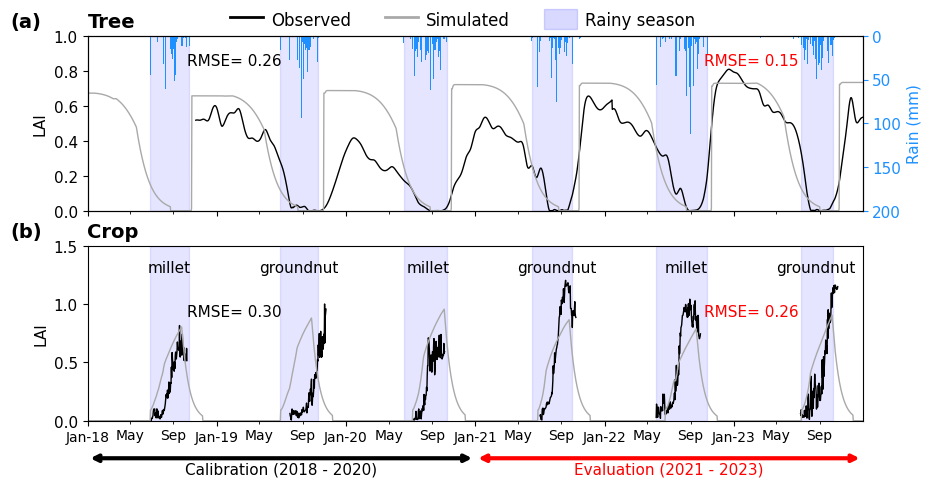

In [19]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, (ax2, ax1) = plt.subplots(2, 1, sharex=True, figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax2.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax1.axvspan(start, end, color='blue', alpha=0.1)
    ax2.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
ax1.plot(df2.index, df2['LAI_Crop_obs'], lw=line_weight, label='LAI_Crop_obs', color=color_obs)
ax1.plot(df2.index, df2['LAI_Crop_orch'], lw=line_weight, label='LAI_Crop_orch', color=color_sim)

# Add crop annotations at June 1st
crops = ['millet', 'groundnut']  # Cycle through these crops
years = df2.index.year.unique()

for i, year in enumerate(years):
    crop = crops[i % len(crops)]  # Alternate between 'millet' and 'peanut'
    date = pd.Timestamp(f'{year}-08-20')
    ax1.text(date, 1.25, crop, color='black', fontsize=11, verticalalignment='bottom', horizontalalignment='center')


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators
#Crop
ax1.text(a_lim, 1, f"RMSE= {results['Calibration LAI_Crop']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax1.text(b_lim, 1, f"RMSE= {results['Validation LAI_Crop']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')
#Tree
ax2.text(a_lim, 0.9, f"RMSE= {results['Calibration LAI_Tree']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax2.text(b_lim, 0.9, f"RMSE= {results['Validation LAI_Tree']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')

ax2.text(-0.1, 1.05, f'({chr(98)})', transform=ax1.transAxes, size=14, weight='bold')
ax1.text(-0.1, 1.05, f'({chr(97)})', transform=ax2.transAxes, size=14, weight='bold')
ax1.set_title("Crop", fontsize=14, loc="left", weight='bold')
ax2.set_title("Tree", fontsize=14, loc="left", weight='bold')

# Set labels and title for the first subplot
ax1.set_ylabel('LAI', fontsize=11)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(200, 0)
ax1.set_ylim(0, 1.5)
ax2.set_ylim(0, 1)

# Plot LAI_Tree_obs and LAI_Tree_orch on the second subplot
line1, = ax2.plot(df2.index, df2['LAI_Tree_obs'], lw=line_weight, label='Observed', color=color_obs)
line2, = ax2.plot(df2.index, df2['LAI_Tree_orch'], lw=line_weight, label='Simulated', color=color_sim)

# Set labels and title for the second subplot
# ax2.set_xlabel('Date')
ax2.set_ylabel('LAI', fontsize=11)

# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax1.set_xlim(df2.index.min(), df2.index.max())
ax2.set_xlim(df2.index.min(), df2.index.max())

# Set x-axis ticks for Jan, May, and Sept
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax2.xaxis.set_major_formatter(DateFormatter("%Y"))
ax2.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax2.tick_params(axis='x', which='major', labelsize=9)
ax2.tick_params(axis='x', which='minor', labelsize=8)
ax2.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax2.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Evaluation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

### Plot GPP

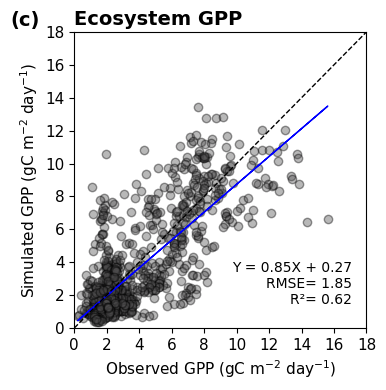

In [228]:

# Calculate statistics
obs = validation_data['GPP_ecosys_obs']
sim = validation_data['GPP_ecosys_orch']


# Plotting
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(obs, sim, color="#4f4e4f", alpha=0.4, edgecolor='black')

# Line of best fit
slope, intercept, r_value, p_value, std_err = linregress(obs, sim)


ax.plot(obs, slope * obs + intercept, color="blue", linewidth=1)

ax.plot([0, 18], [0, 18], 'k--', lw=1)

sign = '-' if intercept < 0 else '+'

# Additional metrics text
metrics_text = f"Y = {slope:.2f}X {sign} {abs(intercept):.2f}\n"\
                f"RMSE= {results['Validation GPP_ecosys']['RMSE']:.2f}\n" \
                f"R²= {results['Validation GPP_ecosys']['R-squared']:.2f}"

ax.text(0.95, 0.07, metrics_text, fontsize=10, va='bottom', ha='right', 
        transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

ax.text(-0.22, 1.02, f'({chr(99)})', transform=ax.transAxes, size=14, weight='bold')


# Labels and title

ax.set_xlabel('Observed GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=11)
ax.set_ylabel('Simulated GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=11)
ax.set_title('Ecosystem GPP', loc='left', pad=5, size=14, weight='bold')
ax.set_xlim([0, 18])
ax.set_ylim([0, 18])
ax.set_xticks(np.arange(0, 19, 2)) 
ax.set_yticks(np.arange(0, 19, 2))
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()


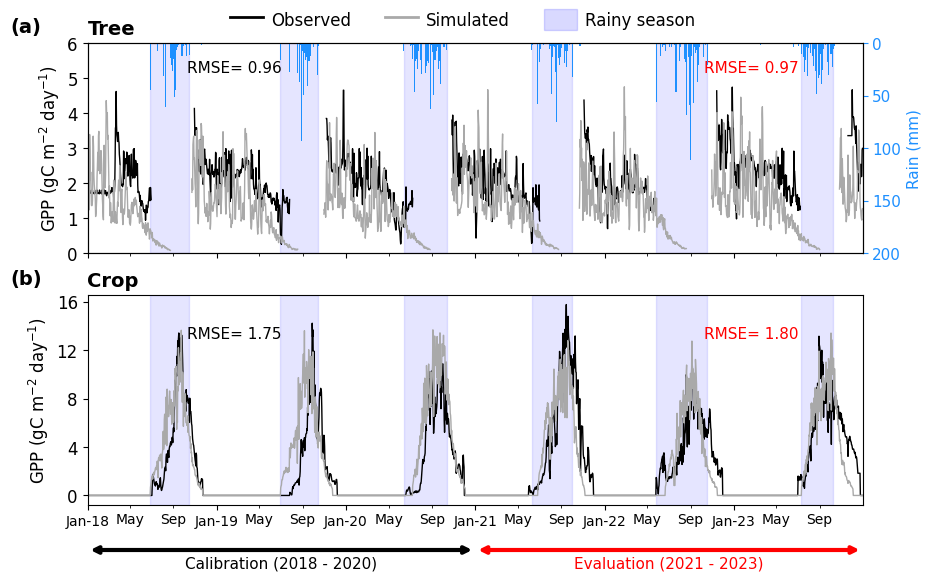

In [20]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, (ax2, ax1) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

# Add the inverted Rain on the secondary y-axis
ax3 = ax2.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax1.axvspan(start, end, color='blue', alpha=0.1)
    ax2.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
ax1.plot(df2.index, df2['GPP_Crop_obs'], lw=line_weight, color=color_obs)
ax1.plot(df2.index, df2['GPP_Crop_orch'], lw=line_weight, color=color_sim)

# # Add crop annotations at June 1st
# crops = ['millet', 'groundnut']  # Cycle through these crops
# years = df2.index.year.unique()

# for i, year in enumerate(years):
#     crop = crops[i % len(crops)]  # Alternate between 'millet' and 'peanut'
#     date = pd.Timestamp(f'{year}-08-20')
#     ax1.text(date, 1.25, crop, color='black', fontsize=11, verticalalignment='bottom', horizontalalignment='center')


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators
#Crop
ax1.text(a_lim, 14, f"RMSE= {results['Calibration GPP_Crop']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax1.text(b_lim, 14, f"RMSE= {results['Validation GPP_Crop']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')
#Tree
ax2.text(a_lim, 5.5, f"RMSE= {results['Calibration GPP_Tree']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax2.text(b_lim, 5.5, f"RMSE= {results['Validation GPP_Tree']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')

ax2.text(-0.1, 1.05, f'({chr(98)})', transform=ax1.transAxes, size=14, weight='bold')
ax1.text(-0.1, 1.05, f'({chr(97)})', transform=ax2.transAxes, size=14, weight='bold')
ax1.set_title("Crop", fontsize=14, loc="left", weight='bold')
ax2.set_title("Tree", fontsize=14, loc="left", weight='bold')

# Set labels and title for the first subplot
ax1.set_ylabel('GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=12)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(200, 0)
ax1.set_yticks(np.arange(0, 20, 4)) 
# ax.set_yticks(np.arange(0, 6, 2))
# ax1.set_ylim(0, 16)
ax2.set_ylim(0, 6)


# Plot LAI_Tree_obs and LAI_Tree_orch on the second subplot
line1, = ax2.plot(df2.index, df2['GPP_Tree_obs'], lw=line_weight, color=color_obs)
line2, = ax2.plot(df2.index, df2['GPP_Tree_orch'], lw=line_weight, color=color_sim)

# Set labels and title for the second subplot
# ax2.set_xlabel('Date')
ax2.set_ylabel('GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=12)

# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax1.set_xlim(df2.index.min(), df2.index.max())
ax2.set_xlim(df2.index.min(), df2.index.max())

# Set x-axis ticks for Jan, May, and Sept
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax2.xaxis.set_major_formatter(DateFormatter("%Y"))
ax2.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax2.tick_params(axis='x', which='major', labelsize=12)
ax2.tick_params(axis='x', which='minor', labelsize=9)
ax2.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax2.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Evaluation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

### Plot NEE

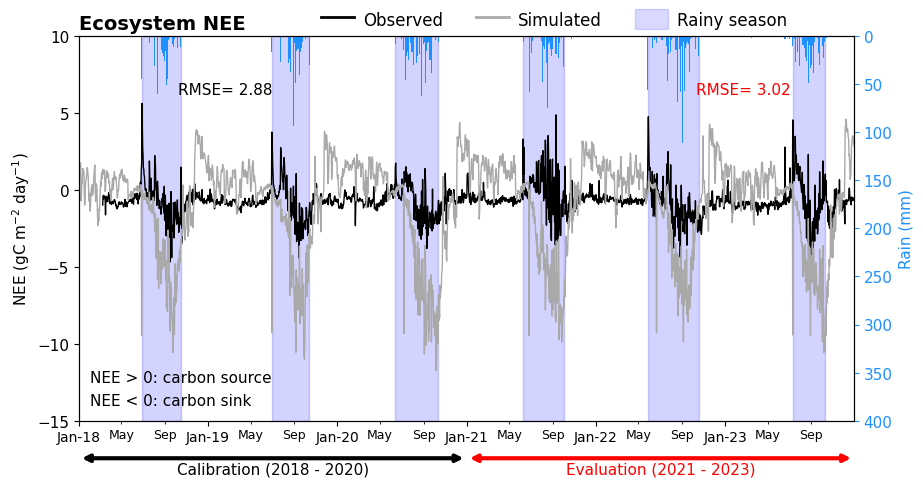

In [21]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, ax = plt.subplots(figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax.axvspan(start, end, color='blue', alpha=0.09)
    ax.axvspan(start, end, color='blue', alpha=0.09)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
line1, = ax.plot(df2.index, df2['NEE_ecosys_obs'], lw=line_weight, color=color_obs)
line2, = ax.plot(df2.index, df2['NEE_ecosys_orch'], lw=line_weight, color=color_sim)



a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators

ax.text(a_lim, 7, f"RMSE= {results['Calibration NEE_ecosys']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax.text(b_lim, 7, f"RMSE= {results['Validation NEE_ecosys']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')


# Set labels and title for the first subplot
ax.set_ylabel('NEE (gC m$^{-2}$ day$^{-1}$)', fontsize=11)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(400, 0)
# ax.set_yticks(np.arange(0, 20, 4)) 
ax.set_ylim(-15, 10)


# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

ax.set_title('Ecosystem NEE', loc='left', pad=5, size=14, weight='bold')
ax.text(df2.index.min() + pd.Timedelta(days=30), -12.5,'NEE > 0: carbon source', fontsize=11)
ax.text(df2.index.min() + pd.Timedelta(days=30), -14,'NEE < 0: carbon sink', fontsize=11)
# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.6, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax.set_xlim(df2.index.min(), df2.index.max())


# Set x-axis ticks for Jan, May, and Sept
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax.tick_params(axis='x', which='major', labelsize=10)
ax.tick_params(axis='x', which='minor', labelsize=9)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Evaluation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

### Plot LE, H and Rn

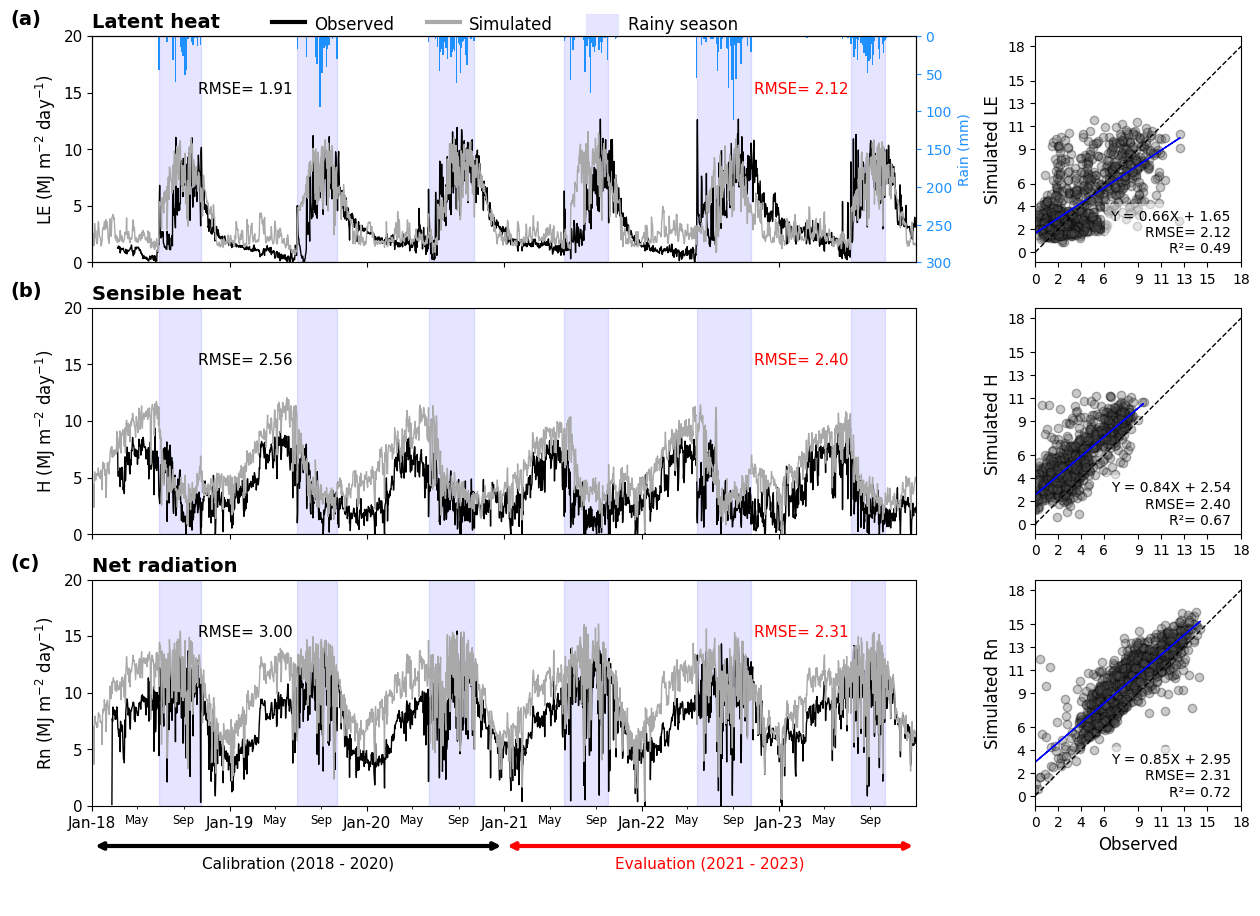

In [10]:

# Variables and units
variables_to_plot = [('LE_ecosys_obs', 'LE_ecosys_orch'), ('H_ecosys_obs', 'H_ecosys_orch'),
                     ('Rn_ecosys_obs', 'Rn_ecosys_orch')]
units = ["LE (MJ m$^{-2}$ day$^{-1}$)", "H (MJ m$^{-2}$ day$^{-1}$)", "Rn (MJ m$^{-2}$ day$^{-1}$)"]

names_variables_to_plot = ["Latent heat", "Sensible heat", "Net radiation"]

color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create subplots for each variable
fig, axes = plt.subplots(len(variables_to_plot), 2, figsize=(15, 10), gridspec_kw={'width_ratios': [3, 0.85]})

for i, (var1, var2) in enumerate(variables_to_plot):
    ax1 = axes[i, 0]  # Left axis for line plot
    ax2 = axes[i, 1]  # Right axis for scatter plot
    
    obs = validation_data[var1]
    sim = validation_data[var2]

    if i == 0:
        ax3 = ax1.twinx()
        ax3.invert_yaxis()
        ax3.bar(df2.index, df2['Rain'], width=4, color=color_rain, label='Rain (mm)')
        ax3.set_ylabel('Rain (mm)', color=color_rain)
        ax3.tick_params(axis='y', colors=color_rain)
        ax3.set_ylim(300,0)

    # Highlight the rainy periods
    for start, end in rainy_seasons:
        ax1.axvspan(start, end, color='blue', alpha=0.1)

    # Add subplot annotation
    axes[i, 0].text(-0.1, 1.05, f'({chr(97 + i)})', transform=axes[i, 0].transAxes, size=14, weight='bold')
    a_lim = df2.index.min() + pd.Timedelta(days=280)
    b_lim = df2.index.max() - pd.Timedelta(days=180)
    
    ax1.text(a_lim, 16, f"RMSE= {results['Calibration '+ var1[:-4]]['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
    ax1.text(b_lim, 16, f"RMSE= {results['Validation '+ var1[:-4]]['RMSE']:.2f}",
            color='red', fontsize=11, va='top', ha='right')

    line1, = ax1.plot(df2.index, df2[var1], color=color_obs, label='Observed', lw=line_weight)
    line2, = ax1.plot(df2.index, df2[var2], color=color_sim, label='Simulated', lw=line_weight)
    ax1.set_title(names_variables_to_plot[i], fontsize=14, loc="left", fontweight='bold')
    ax1.set_ylabel(f'{units[i]}', fontsize=12)

    ax2.scatter(obs, sim, color="#4f4e4f", alpha=0.3, edgecolor='black')
    
    slope, intercept, r_value, p_value, std_err = linregress(obs, sim)
    
    ax2.plot(obs, slope * obs + intercept, color="blue", linewidth=1)

    ax2.plot([0, 18], [0, 18], 'k--', lw=1)

    sign = '-' if intercept < 0 else '+'

    ax1.set_xlim(df2.index.min(), df2.index.max())
    ax1.tick_params(axis='x', which='major', labelsize=11)
    ax1.tick_params(axis='x', which='minor', labelsize=8.5)
    ax1.tick_params(axis='y', labelsize=11)
    
    ax1.set_ylim(0, 20)
    ax2.set_xlim(0, 18)
    ax1.set_yticks(np.floor(np.linspace(0, 20, 5)))
    
    ax2.set_xticks(np.floor(np.linspace(0, 18, 9)))
    ax2.set_yticks(np.floor(np.linspace(0, 18, 9)))
    ax2.set_aspect('equal', adjustable='box')
    ax2.set_xlabel(f'Observed', fontsize=11)
    ax2.set_ylabel(f'Simulated {units[i][:2]}', fontsize=12)
    date_form = DateFormatter("%b-%y")

    # Additional metrics text
    metrics_text = f"Y = {slope:.2f}X {sign} {abs(intercept):.2f}\n"\
                f"RMSE= {results['Validation '+ var1[:-4]]['RMSE']:.2f}\n" \
                f"R²= {results['Validation ' + var1[:-4]]['R-squared']:.2f}"
                
    ax2.text(0.95, 0.03, metrics_text, fontsize=10, va='bottom', ha='right', 
            transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    if i != len(variables_to_plot) - 1:
        ax1.set_xlabel('')
        ax1.set_xticklabels([])
        ax2.set_xlabel('')
    else:
        ax1.xaxis.set_major_locator(YearLocator())
        ax1.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
        ax1.xaxis.set_major_formatter(DateFormatter("%Y"))
        ax1.xaxis.set_minor_formatter(DateFormatter("%b"))
        ax1.xaxis.set_major_formatter(date_form)
        ax1.tick_params(axis='y', labelsize=11)
        ax2.set_xlabel(f'Observed', fontsize=12)

rain_patch = Patch(color='blue', alpha=0.1, label='Rainy season', linewidth=0.1)
legend_lines = [Line2D([0], [0], color=color_obs, linewidth=3),
                Line2D([0], [0], color=color_sim, linewidth=3),
                rain_patch]
fig.legend(legend_lines, ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, fontsize=12, bbox_to_anchor=(0.4, 0.91), 
           frameon=False,     
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=1.0,       
           borderpad=0.0,          
           handletextpad=0.5       
           )

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.12])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.35, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.35, 'Evaluation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

# plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

### Plot Reco

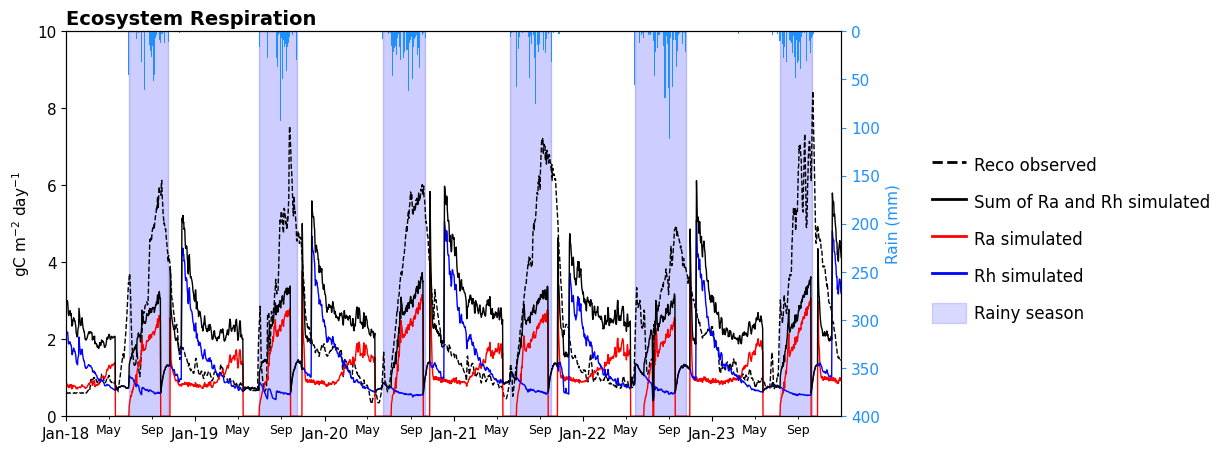

In [11]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, ax = plt.subplots(figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax.axvspan(start, end, color='blue', alpha=0.1)
    ax.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
line1, = ax.plot(df2.index, df2['Reco_ecosys_obs'], "k--", lw=line_weight, label="Reco observed")
line2, = ax.plot(df2.index, df2['Ra_ecosys_orch'], "r", lw=line_weight, label="Ra simulated")
line3, = ax.plot(df2.index, df2['Rh_ecosys_orch'], "b", lw=line_weight, label="Rh simulated")
line4, = ax.plot(df2.index, df2['Sum_Ra_Rh_ecosys_orch'], "k", lw=line_weight, label="Sum of Ra and Rh simulated")


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators

# Set labels and title for the first subplot
ax.set_ylabel('gC m$^{-2}$ day$^{-1}$', fontsize=11)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(400, 0)
# ax.set_yticks(np.arange(0, 20, 4)) 
ax.set_ylim(0, 10)


# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color="black", lw=2, ls="--", label='Reco observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color="red", lw=2, label='Ra simulated')
line3 = Line2D([0], [0], color="blue", lw=2, label='Rh simulated')
line4 = Line2D([0], [0], color="black", lw=2, label='Sum of Ra and Rh simulated')

ax.set_title('Ecosystem Respiration', loc='left', pad=5, size=14, weight='bold')

# Add a legend for the lines and patch
fig.legend([line1, line4, line2, line3, rain_patch],
           ["Reco observed", "Sum of Ra and Rh simulated", "Ra simulated", "Rh simulated", "Rainy season"],
           loc='upper center', ncol=1, bbox_to_anchor=(1.13, 0.65), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=1.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax.set_xlim(df2.index.min(), df2.index.max())


# Set x-axis ticks for Jan, May, and Sept
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax.tick_params(axis='x', which='major', labelsize=11)
ax.tick_params(axis='x', which='minor', labelsize=9)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax.xaxis.set_major_formatter(date_form)

plt.show()

### Anomalies 

In [4]:
df3 = pd.read_excel("Data_source_paper_biogeosciences.xlsx", sheet_name="SimWaterPlot")

In [ ]:
"""
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

data = df3.copy()
# Create a dictionary to map month names to numbers
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Map the 'Month' column to its numeric equivalent
data['Month'] = data['Month'].map(month_map)

# Now create the 'Date' column
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))
# Assuming 'data' dataframe is already available
anoR = data['Ano_Rain_%']
anoGW = data['Ano_SWCC_%']
gppCrop = data["R_varSWCC_avg_gppCrop_%"]
gppTree = data['R_avgSWCC_var_gppTree_%']
# gppEcosys = data['R_varSWCC_var_gppEcosys_%']
gppCropVarfull = data['R_varSWCC_var_gppCrop_%']
gppTreeVarfull = data['R_varSWCC_var_gppTree_%']


fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1, 2, 2]})

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.2)  # Increase this value for more space

color_rain = "red"
color_swcc = "black"
color_all = "darkgrey"
# Plot AnoR as a barplot on the first axis
axs[0].bar(data['Date'], anoR, color='red', label='AnoR', width=7)
axs[0].set_ylabel('Rain \n anomaly (%)')
# axs[0].set_title('Rainfall anomaly', loc='left', pad=5, size=11)
axs[0].axhline(0, color='black', linestyle='-', lw=0.5)
axs[0].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[0].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[0].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
# axs[0].set_yticks([-150., -100, -50., 0., 50., 100.])
axs[0].set_yticks([-100, 0., 100, 200, 300, 400])
axs[0].set_ylim([-100., 400])

axs[0].text(0.02, 0.8, f'({chr(97)})', transform=axs[0].transAxes, size=12, weight='bold')
axs[1].text(0.02, 0.8, f'({chr(98)})', transform=axs[1].transAxes, size=12, weight='bold')
axs[2].text(0.02, 0.9, f'({chr(99)})', transform=axs[2].transAxes, size=12, weight='bold')
axs[3].text(0.02, 0.9, f'({chr(100)})', transform=axs[3].transAxes, size=12, weight='bold')

# Create a patch for the rainy season
# rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
# # Add a legend for the lines and patch
# axs[2].legend([rain_patch],
#            ["Rainy season"],
#            loc='upper center', ncol=1, bbox_to_anchor=(0.9, 1.12), frameon=False, 
#            fontsize=11,
#            handlelength=2,         
#            handleheight=1.0,       
#            labelspacing=1.0,       
#            borderpad=0.0,          
#            handletextpad=0.5)

# Plot AnoGW as a barplot on the second axis
axs[1].bar(data['Date'], anoGW, color='black', label='AnoGW', width=7)
axs[1].set_ylabel('SWCC \n anomaly (%)') #(m$^{3}$ m$^{-3}$)
# axs[1].set_title('SWCC anomaly', loc='left', pad=5, size=11)
axs[1].axhline(0, color='black', linestyle='-', lw=0.5)
axs[1].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[1].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[1].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[1].set_yticks([-50, -25, 0., 25, 50, 75])
axs[1].set_ylim([-50., 75])
# axs[2].set_yticks([-70., -30., 0., 30., 60., 90])

# axs[3].set_ylim([-105., 100])
# axs[3].set_yticks([-105., -50., 0., 50., 100])

# Set the general title part without the colored sections
# axs[2].set_title('Crop GPP '+ r'(     ${R_{var}SWCC_{avg}}$)'+ '     Crop GPP ' + r'(     ${R_{var}SWCC_{var}}$)', loc='left', pad=5, size=11)

# # Set the general title part without the colored sections
# axs[3].set_title('Tree GPP '+ r'(     ${R_{avg}SWCC_{var}}$)'+ '     Tree GPP ' + r'(     ${R_{var}SWCC_{var}}$)', loc='left', pad=5, size=11)

# # # Add red band as a rectangle behind the first math expression
# red_band = patches.Rectangle((0.14, 1.05), 0.025, 0.01, transform=axs[2].transAxes, 
#                              color=color_rain, clip_on=False)
# axs[2].add_patch(red_band)

# gray_band = patches.Rectangle((0.505, 1.05), 0.025, 0.01, transform=axs[2].transAxes, 
#                              color=color_all, clip_on=False)
# axs[2].add_patch(gray_band)

# black_band = patches.Rectangle((0.14, 1.05), 0.025, 0.01, transform=axs[3].transAxes, 
#                              color=color_swcc, clip_on=False)
# axs[3].add_patch(black_band)

# gray_band = patches.Rectangle((0.505, 1.05), 0.025, 0.01, transform=axs[3].transAxes, 
#                              color=color_all, clip_on=False)
# axs[3].add_patch(gray_band)

# # Plot GPP on the third axis
axs[2].axhline(0, color='black', linestyle='-', lw=1.5, alpha=0.8)
axs[2].plot(data['Date'], gppCropVarfull, label='gppEcosys', color='darkgrey', alpha=0.8)
axs[2].plot(data['Date'], gppCrop, label='gppCrop', color='red', alpha=0.8)


axs[3].axhline(0, color='red', linestyle='-', lw=1.5, alpha=0.8)
axs[3].plot(data['Date'], gppTreeVarfull, label='gppEcosys', color='darkgrey', alpha=0.8)
axs[3].plot(data['Date'], gppTree, label='gppTree', color='black', alpha=0.8)

rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
legend_lines = [Line2D([0], [0], color="red", linewidth=3),
                Line2D([0], [0], color="black", linewidth=3),
                Line2D([0], [0], color="darkgrey", linewidth=3), rain_patch]
axs[2].legend(legend_lines, [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', r'${R_{var}SWCC_{var}}$',"Rainy season"],
           loc='upper center', ncol=1, fontsize=10, bbox_to_anchor=(0.10, 0.55), 
           frameon=False,     
           handlelength=1,         
           handleheight=1.,       
           labelspacing=0.25,       
           borderpad=0.0,          
           handletextpad=0.25)

axs[2].set_ylabel('Crop GPP \n anomaly (%)')
axs[3].set_ylabel('Tree GPP \n anomaly (%)')

axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)


# # Formatting x-axis
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axs[3].xaxis.set_major_locator(YearLocator())
axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
axs[3].tick_params(axis='y', labelsize=10)
axs[3].tick_params(axis='x', which='major', labelsize=11)
axs[3].tick_params(axis='x', which='minor', labelsize=9)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
axs[3].xaxis.set_major_formatter(date_form)

# Show the plots
plt.show()


"""

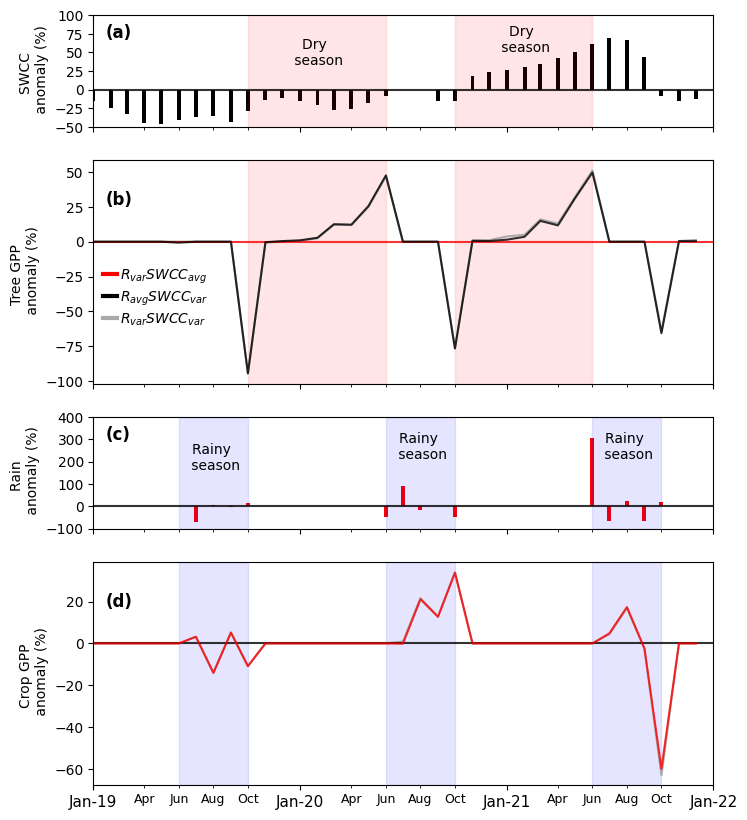

In [38]:
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
from matplotlib.lines import Line2D

data = df3.copy()

# Create a dictionary to map month names to numbers
month_map = {month: i + 1 for i, month in enumerate(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}

# Map the 'Month' column to its numeric equivalent and create the 'Date' column
data['Month'] = data['Month'].map(month_map)
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))

# Extract data for plotting
anoR = data['Ano_Rain_%']
anoGW = data['Ano_SWCC_%']
gppCrop = data["R_varSWCC_avg_gppCrop_%"]
gppTree = data['R_avgSWCC_var_gppTree_%']
gppCropVarfull = data['R_varSWCC_var_gppCrop_%']
gppTreeVarfull = data['R_varSWCC_var_gppTree_%']

# Set up subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True, gridspec_kw={'height_ratios': [1, 2, 1, 2]})
plt.subplots_adjust(hspace=0.2)  # Adjust spacing between subplots

colors = {'rain': "red", 'swcc': "black", 'gppCropVarfull': "darkgrey", 
          'gppTreeVarfull': "darkgrey",'gppCrop': "red", 'gppTree': "black"}

# Plot data in subplots
plot_data = [
    (axs[0], data['Date'], anoGW, 'SWCC \n anomaly (%)', colors['swcc']),
    (axs[1], data['Date'], gppTreeVarfull, 'Tree GPP \n anomaly (%)', colors['gppTreeVarfull'], gppTree),
    (axs[2], data['Date'], anoR, 'Rain \n anomaly (%)', colors['rain']),
    (axs[3], data['Date'], gppCropVarfull, 'Crop GPP \n anomaly (%)', colors['gppCropVarfull'], gppCrop),
]

for i, (ax, x, y, ylabel, color, *additional) in enumerate(plot_data):
    if i == 0 or i == 2:
        ax.bar(x, y, color=color, width=7)
    else:
        ax.plot(x, y, color=color)
    ax.axhline(0, color="red" if "Tree" in ylabel else "black", linestyle='-', lw=1.5, alpha=0.8)
    if ylabel:
        ax.set_ylabel(ylabel)
    if additional:
        for additional_y in additional:
            ax.plot(x, additional_y, color="black" if "Tree" in ylabel else "red", alpha=0.8)

# Add season spans and labels
seasons = {
    "Rainy": [(pd.Timestamp(f'{year}-06-01'), pd.Timestamp(f'{year}-10-01')) for year in range(2019, 2022)],
    "Dry": [(pd.Timestamp(f'{year}-10-01'), pd.Timestamp(f'{year + 1}-06-01')) for year in range(2019, 2021)]
}

# Loop through the "Rainy season" spans for axs[0] and axs[1]
for i, ax in enumerate(axs[:2]):
    for start, end in seasons["Dry"]:
        ax.axvspan(start, end, color='red', alpha=0.1)
        if i == 0:
            ax.text(start + (end - start)/2, ax.get_ylim()[1]-ax.get_ylim()[1]/3, "Dry \n season", ha='center', va='center', color='black')
            ax.set_yticks([-50, -25, 0., 25, 50, 75, 100])
            ax.set_ylim([-50., 100])

# Loop through the "Dry season" spans for axs[2] and axs[3]
for i, ax in enumerate(axs[2:], start=2):
    for start, end in seasons["Rainy"]:
        ax.axvspan(start, end, color='blue', alpha=0.1)
        if i == 2:
            ax.text(start + (end - start)/2, ax.get_ylim()[1]-ax.get_ylim()[1]/3, "Rainy \n season", ha='center', va='center', color='black')
            ax.set_yticks([-100, 0., 100, 200, 300, 400])
            ax.set_ylim([-100., 400])
# Add labels for each subplot
for i, label in enumerate(['(a)', '(b)', '(c)', '(d)']):
    axs[i].text(0.02, 0.8, label, transform=axs[i].transAxes, size=12, weight='bold')

# # Formatting x-axis
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axs[3].xaxis.set_major_locator(YearLocator())
axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
axs[3].tick_params(axis='y', labelsize=10)
axs[3].tick_params(axis='x', which='major', labelsize=11)
axs[3].tick_params(axis='x', which='minor', labelsize=9)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
axs[3].xaxis.set_major_formatter(date_form)
axs[3].set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'))

# Legend
legend_lines = [Line2D([0], [0], color=color, linewidth=3) for color in [colors['rain'], colors['swcc'], colors['gppCropVarfull']]]
axs[1].legend(legend_lines, [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', r'${R_{var}SWCC_{var}}$'], loc='upper center', ncol=1, fontsize=10, bbox_to_anchor=(0.10, 0.55), frameon=False, handlelength=1, handleheight=1., labelspacing=0.25, borderpad=0.0, handletextpad=0.25)

# Show the plots
plt.show()


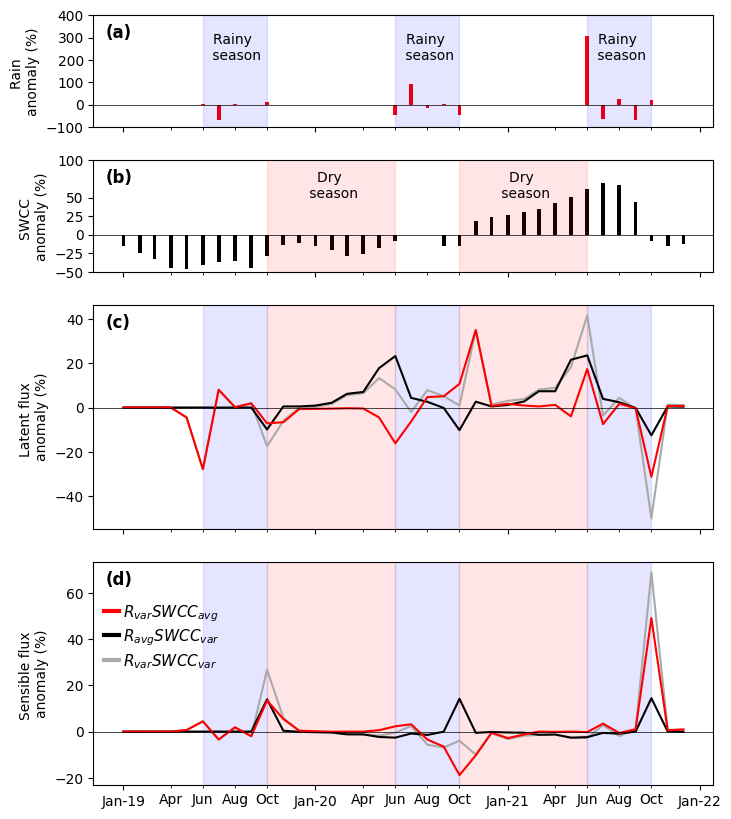

In [ ]:
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

data = df3.copy()
# Create month mapping and date column
month_map = {m: i + 1 for i, m in enumerate(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
             
# Map the 'Month' column to its numeric equivalent
data['Month'] = data['Month'].map(month_map)

# Now create the 'Date' column
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))
# Assuming 'data' dataframe is already available
anoR = data['Ano_Rain_%']
anoGW = data['Ano_SWCC_%']


lat_robs = data["R_varSWCC_avg_fluxlat_%"]
lat_gwobs = data['R_avgSWCC_var_fluxlat_%']
lat_robs_gwobs = data['R_varSWCC_var_fluxlat_%']

sens_robs = data["R_varSWCC_avg_fluxsens_%"]
sens_gwobs = data['R_avgSWCC_var_fluxsens_%']
sens_robs_gwobs = data['R_varSWCC_var_fluxsens_%']

fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1, 2, 2]})

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.2)  # Increase this value for more space

color_rain = "red"
color_swcc = "black"
color_all = "darkgrey"
# Plot AnoR as a barplot on the first axis
axs[0].bar(data['Date'], anoR, color='red', label='AnoR', width=7)
axs[0].set_ylabel('Rain \nanomaly (%)')
# axs[0].set_title('Rainfall anomaly', loc='left', pad=5, size=11)
axs[0].axhline(0, color='black', linestyle='-', lw=0.5)
# axs[0].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
# axs[0].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
# axs[0].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[0].set_yticks([-100, 0., 100, 200, 300, 400])
axs[0].set_ylim([-100., 400])

# Plot AnoGW as a barplot on the second axis
axs[1].bar(data['Date'], anoGW, color='black', label='AnoGW', width=7)
axs[1].set_ylabel('SWCC \nanomaly (%)')
# axs[1].set_title('SWCC anomaly', loc='left', pad=5, size=11)
axs[1].axhline(0, color='black', linestyle='-', lw=0.5)
# axs[1].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
# axs[1].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
# axs[1].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[1].set_yticks([-50, -25, 0., 25, 50, 100])
axs[1].set_ylim([-50., 100])


# # Set the general title part without the colored sections
# axs[2].set_title('Latent flux', loc='left', pad=5, size=11)
# axs[3].set_title('Sensible flux', loc='left', pad=5, size=11)

# Define spans and labels for each season
seasons = {
    "Rainy \n season": [(pd.Timestamp('2019-06-01'), pd.Timestamp('2019-10-01')),
                     (pd.Timestamp('2020-06-01'), pd.Timestamp('2020-10-01')),
                     (pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'))],
    "Dry \n season": [(pd.Timestamp('2019-10-01'), pd.Timestamp('2020-06-01')),
                   (pd.Timestamp('2020-10-01'), pd.Timestamp('2021-06-01'))]
}

# Loop through the "Rainy season" spans for axs[0]
for start, end in seasons["Rainy \n season"]:
    axs[0].axvspan(start, end, color='blue', alpha=0.1)
    axs[0].text(start + (end - start) / 2, axs[0].get_ylim()[1]- axs[0].get_ylim()[1]/2, "Rainy \n season", ha='center', color='black')

# Loop through the "Dry season" spans for axs[1]
for start, end in seasons["Dry \n season"]:
    axs[1].axvspan(start, end, color='red', alpha=0.1)
    axs[1].text(start + (end - start) / 2, axs[1].get_ylim()[1] - axs[1].get_ylim()[1]/2, "Dry \n season", ha='center', color='black')

# Loop through both "Rainy season" and "Dry season" spans for axs[2] and axs[3]
for ax in axs[2:]:
    for start, end in seasons["Rainy \n season"]:
        ax.axvspan(start, end, color='blue', alpha=0.1)
        # ax.text(start + (end - start) / 2, ax.get_ylim()[1] - ax.get_ylim()[1]/3, "Rainy \n season", ha='center', color='black', alpha=0.7)
    for start, end in seasons["Dry \n season"]:
        ax.axvspan(start, end, color='red', alpha=0.1)
        # ax.text(start + (end - start) / 2, ax.get_ylim()[1] - ax.get_ylim()[1]/3, "Dry \n season", ha='center', color='black', alpha=0.7)


# # Plot GPP on the third axis
axs[2].plot(data['Date'], lat_robs_gwobs, label='R_varSWCC_var_fluxlat', color='darkgrey')
axs[2].plot(data['Date'], lat_gwobs, label='R_avgSWCC_var_fluxlat', color='black')
axs[2].plot(data['Date'], lat_robs, label='R_varSWCC_avg_fluxlat', color='red')

axs[2].axhline(0, color='black', linestyle='-', lw=0.5)

axs[3].plot(data['Date'], sens_robs_gwobs, label='R_varSWCC_var_fluxlat', color='darkgrey')
axs[3].plot(data['Date'], sens_gwobs, label='R_avgSWCC_var_fluxlat', color='black')
axs[3].plot(data['Date'], sens_robs, label='R_varSWCC_avg_fluxlat', color='red')

axs[3].axhline(0, color='black', linestyle='-', lw=0.5)


axs[2].set_ylabel('Latent flux \nanomaly (%)')
axs[3].set_ylabel('Sensible flux \nanomaly (%)')
# axs[2].legend(loc='upper right')
# axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
# axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
# axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
# axs[3].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
# axs[3].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
# axs[3].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
# axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
# axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
# axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)

axs[0].text(0.02, 0.8, f'({chr(97)})', transform=axs[0].transAxes, size=12, weight='bold')
axs[1].text(0.02, 0.8, f'({chr(98)})', transform=axs[1].transAxes, size=12, weight='bold')
axs[2].text(0.02, 0.9, f'({chr(99)})', transform=axs[2].transAxes, size=12, weight='bold')
axs[3].text(0.02, 0.9, f'({chr(100)})', transform=axs[3].transAxes, size=12, weight='bold')

# # Formatting x-axis
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axs[3].xaxis.set_major_locator(YearLocator())
axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
axs[3].tick_params(axis='y', labelsize=10)
axs[3].tick_params(axis='x', labelsize=10)
# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
axs[3].xaxis.set_major_formatter(date_form)
from matplotlib.lines import Line2D
# rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
legend_lines = [Line2D([0], [0], color="red", linewidth=3),
                Line2D([0], [0], color="black", linewidth=3),
                Line2D([0], [0], color="darkgrey", linewidth=3)]
axs[3].legend(legend_lines, [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', r'${R_{var}SWCC_{var}}$'],
           loc='upper center', ncol=1, fontsize=11, bbox_to_anchor=(0.11, 0.85), 
           frameon=False,     
           handlelength=1,         
           handleheight=1.,       
           labelspacing=0.25,       
           borderpad=0.0,          
           handletextpad=0.25)

# # Create a patch for the rainy season
# rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
# # Add a legend for the lines and patch
# fig.legend([rain_patch],
#            ["Rainy season"],
#            loc='upper center', ncol=1, bbox_to_anchor=(0.5, 0.906), frameon=False, 
#            fontsize=11,
#            handlelength=2,         
#            handleheight=1.0,       
#            labelspacing=1.0,       
#            borderpad=0.0,          
#            handletextpad=0.5)

# Align the x-axis labels and improve plot aesthetics
# plt.tight_layout()

# Show the plots
plt.show()

In [6]:
import math

# Given data
average_canopy_radius = 5.39  # meters
trees_in_plot = 13  # number of trees in the mesh
hectare_area = 10000  # m² (1 hectare)

# Step 1: Calculate the area covered by a single tree canopy (Area of a circle)
single_tree_canopy_area = math.pi * average_canopy_radius ** 2

# Step 2: Calculate the total area covered by all trees
total_canopy_area = single_tree_canopy_area * trees_in_plot

# Step 3: Calculate the proportion of the area covered by the canopy in the mesh
proportion_of_canopy_cover = total_canopy_area / hectare_area

(single_tree_canopy_area, total_canopy_area, proportion_of_canopy_cover)

(1186.5082311076283, 0.11865082311076283)

In [10]:

# Solve for the radius when the total canopy area is 15%
# total_canopy_area = math.pi * r^2 * number_of_trees
# r^2 = desired_total_canopy_area / (math.pi * number_of_trees)

# For the second part of the question, let's calculate the canopy radius and area when canopy cover is 15%
desired_proportion = 0.15
desired_total_canopy_area = desired_proportion * hectare_area

canopy_radius_for_15_percent_cover = math.sqrt(desired_total_canopy_area / (math.pi * trees_in_plot))

# Canopy area for a single tree at 15% cover
single_tree_canopy_area_15_percent = math.pi * canopy_radius_for_15_percent_cover ** 2

(canopy_radius_for_15_percent_cover, single_tree_canopy_area_15_percent)


(6.060368288349924, 115.38461538461539)

In [12]:
116*13



1508

Figure 6: Time series of modeled and measured Net Ecosystem Exchange (NEE) at ecosystem scale at the daily time step. Calibration metrics are in black and validation metrics in red. Negative values represent the flux into the biosphere, whereas positive values the flux towards the atmosphere.

In [2]:
import pandas as pd

j = pd.read_clipboard()

In [3]:
j.sample(5)

,Import_datetime,Mean_Tree_LAI_Towerplot_m2leafm2
92437,10/4/2023 18:45,0.600148
17638,3/1/2019 11:15,0.577386
115041,24/07/2024 16:45,NaN
91076,13/03/2023 10:15,0.685187
99087,27/08/2023 07:45,0.005683


In [4]:

df = j.copy()
# Convert the 'Import_datetime' column to datetime format
df['Import_datetime'] = pd.to_datetime(df['Import_datetime'], dayfirst=True)

# Filter data before 2024
df_filtered = df[df['Import_datetime'].dt.year < 2024]

# Group by day and calculate the daily mean for 'Mean_Tree_LAI_Towerplot_m2leafm2'
df_daily_mean = df_filtered.resample('D', on='Import_datetime').mean().reset_index()

# Display the result
print(df_daily_mean)


     Import_datetime  Mean_Tree_LAI_Towerplot_m2leafm2
0         2018-01-01                               NaN
1         2018-01-02                               NaN
2         2018-01-03                               NaN
3         2018-01-04                               NaN
4         2018-01-05                               NaN
...              ...                               ...
2186      2023-12-27                          0.529172
2187      2023-12-28                          0.530543
2188      2023-12-29                          0.531685
2189      2023-12-30                          0.532662
2190      2023-12-31                          0.533535

[2191 rows x 2 columns]


In [6]:
df_daily_mean.to_clipboard()

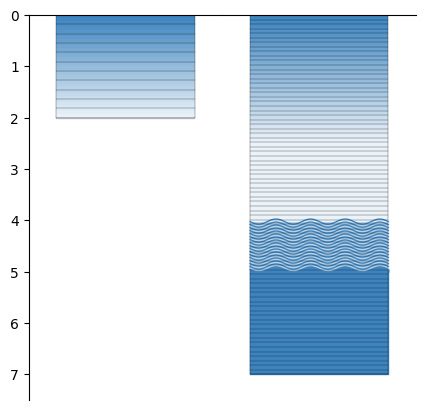

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Set up the figure
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(5, 5), sharey=True)

# Depth parameters
total_depth = 7  # in meters
num_layers = 120  # total layers
layer_thickness = total_depth / num_layers

# Define color regions based on depth
depths = np.linspace(0, total_depth, num_layers + 1)

start_color = np.array([0x3d / 255, 0x84 / 255, 0xbf / 255])  # #3d84bf
end_color = np.array([0xef / 255, 0xf5 / 255, 0xfa / 255])    # #eff5fa

# Left plot: Gradient blue from 0 to 2 meters
for i in range(num_layers):
    depth = depths[i]
    top = depths[i + 1]
    
    if depth < 2:
        # Gradient blue from 0 to 2 m for the left part
        color_intensity = depth / 2  # Scale from 0 to 1 as depth goes from 0 to 2 m
        current_color = (1 - color_intensity) * start_color + color_intensity * end_color
        ax_left.add_patch(patches.Rectangle((0, depth), 1, layer_thickness, color=current_color, ec='none'))  # Left plot

# Right plot: Full profile from 0 to 7 meters
for i in range(num_layers):
    depth = depths[i]
    top = depths[i + 1]
    
    if depth < 2.5:
        # Gradient blue from 0 to 2.5 m for the right part
        color_intensity = depth / 2.5  # Scale from 0 to 1 as depth goes from 0 to 2.5 m
        current_color = (1 - color_intensity) * start_color + color_intensity * end_color
        ax_right.add_patch(patches.Rectangle((0, depth), 1, layer_thickness, color=current_color, ec='none'))  # Right plot
    elif 2.5 <= depth < 4:
        # Uniform light blue from 2.5 to 4 m for the right part
        ax_right.add_patch(patches.Rectangle((0, depth), 1, layer_thickness, color=current_color, ec='none'))  # Right plot
    elif 4 <= depth < 5:
        # Uniform color in the 4–5 m layer
        ax_right.add_patch(patches.Rectangle((0, depth), 1, layer_thickness, color="#b7d2e8", ec='none'))  # Right plot
        
        # Adding oscillation effect at each sub-layer within 4–5 m
        wave_amplitude = 0.05  # Amplitude of the wave
        wave_frequency = 8  # Frequency of the wave
        x_wave = np.linspace(0, 1, 500)
        y_wave = depth + wave_amplitude * np.sin(wave_frequency * np.pi * x_wave)
        ax_right.plot(x_wave, y_wave, color=start_color, linewidth=1)  # Right plot
    elif 5 <= depth < 5 + layer_thickness:
        # Fill the oscillating area and ensure no gaps at 5 m
        ax_right.fill_between(x_wave, 5, y_wave, color=start_color, alpha=1)  # Right plot
        ax_right.fill_betweenx([5, 7], 0, 1, color=start_color, alpha=1)  # Right plot
    else:
        # Saturation layer from 5 to 7 m, solid blue
        ax_right.add_patch(patches.Rectangle((0, depth), 1, layer_thickness, color=start_color, ec='none'))  # Right plot

# Set axis limits and labels
ax_left.set_ylim(7.5, 0)  # Depth increases downwards
ax_left.set_xlim(-0.2, 1.2)
ax_right.set_xlim(-0.2, 1.2)

# Hide x-axis ticks and labels for both plots
ax_left.set_xticks([])
ax_right.set_xticks([])
ax_right.tick_params(width=0)
# Set y-ticks for the left plot
ax_left.set_yticks(np.arange(0, total_depth + 1, 1))

# Remove the spines (borders) for both plots
for i, ax in enumerate([ax_left, ax_right]):
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['right'].set_visible(False)
    else:
        ax.spines['left'].set_visible(False)


# Add 11 horizontal lines between 0 and 2 meters on the left plot
line_positions = np.linspace(0, 2, 12)[1:]  # Create 11 positions between 0 and 2 meters

# Add 11 horizontal lines between 0 and 2 meters on the left plot (only between x=0 and x=1)
line_positions_left = np.linspace(0, 2, 12)[1:]  # Create 11 positions between 0 and 2 meters
line_positions_right = np.linspace(0, 7, 80)[1:]  # Create 120 positions between 0 and 7 meters
for pos in line_positions_left:
    ax_left.plot([0, 1], [pos, pos], color='black', ls='-', lw=0.2)  # Horizontal line from x=0 to x=1

for pos_r in line_positions_right:
    ax_right.plot([0, 1], [pos_r, pos_r], color='black', ls='-', lw=0.2)  # Horizontal line from x=0 to x=1

# adding rectangles with black borders but no fill color to the left and right subplots.
ax_left.add_patch(patches.Rectangle((0, 0), 1, 2, color="none", ec='black', lw=0.2))
ax_right.add_patch(patches.Rectangle((0, 0), 1, 7, color="none", ec='black', lw=0.2))

# Adjust layout to remove any space between the two subplots
plt.subplots_adjust(wspace=0)

# Show the plot with no gap between the subplots
plt.show()


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, YearLocator, MonthLocator
from matplotlib.lines import Line2D

def create_subplot_params():
    return {
        'crop': {
            'ylabel': 'Crop GPP \n(gC m$^{-2}$ day$^{-1}$)',
            'yticks': [0, 4, 8, 12, 16],
            'ylim': (0, 16),
            'vars': [
                ('R_avgSWCC_avg_gppCrop', 'R_varSWCC_avg_gppCrop', "#2c32f2", "red"),
                ('R_avgSWCC_avg_gppCrop', 'R_avgSWCC_var_gppCrop', "#2c32f2", "black"),                
                ('R_avgSWCC_avg_gppCrop', 'R_varSWCC_var_gppCrop', "#2c32f2", "darkgrey")
            ]
        },
        'tree': {
            'ylabel': 'Tree GPP \n(gC m$^{-2}$ day$^{-1}$)',
            'yticks': [0, 1, 2, 3, 4, 5],
            'ylim': (0, 5),
            'vars': [
                ('R_avgSWCC_avg_gppTree', 'R_varSWCC_avg_gppTree', "#2c32f2", "red"),
                ('R_avgSWCC_avg_gppTree', 'R_avgSWCC_var_gppTree', "#2c32f2", "black"),
                ('R_avgSWCC_avg_gppTree', 'R_varSWCC_var_gppTree', "#2c32f2", "darkgrey")
            ]
        }
    }

def plot_seasonal_data(file_path):
    # Load and prepare data
    data = pd.read_csv(file_path)
    data['time_counter'] = pd.to_datetime(data['time_counter'], format='%m/%d/%Y %H:%M')
    
    # Create subplots
    fig, axes = plt.subplots(6, 1, figsize=(7, 8), sharex=True)
    params = create_subplot_params()
    line_weight = 1
    
    # Plot rainy seasons
    rainy_seasons = []
    for year, group in data.groupby(data['time_counter'].dt.year):
        rain_dates = group[group['Rain_avg'] > 5]['time_counter']
        if not rain_dates.empty:
            rainy_seasons.append((rain_dates.min(), rain_dates.max()))
    
    # Plot dry periods
    dry_periods = [
        (pd.Timestamp('2019-10-01'), pd.Timestamp('2020-06-01')),
        (pd.Timestamp('2020-10-01'), pd.Timestamp('2021-06-01'))
    ]
    
    # Create plots for both crop and tree data
    for i, (param_type, param_data) in enumerate([('crop', params['crop']), ('tree', params['tree'])]):
        offset = i * 3
        for j, (var1, var2, color1, color2) in enumerate(param_data['vars']):
            ax = axes[offset + j]
            
            # Plot data
            ax.plot(data['time_counter'], data[var1], label=var1, color=color1, lw=line_weight)
            ax.plot(data['time_counter'], data[var2], label=var2, color=color2, lw=line_weight)
            
            # Set axes properties
            ax.set_ylabel(param_data['ylabel'], fontsize=10)
            ax.set_yticks(param_data['yticks'])
            ax.set_ylim(param_data['ylim'])
            
            # Add seasonal highlights
            if param_type == 'crop':
                for start, end in rainy_seasons:
                    ax.axvspan(start, end, color='blue', alpha=0.08)
                    if j == 0:
                        mid_point = start + (end - start) / 2
                        ax.text(mid_point, 13.8, 'Rainy', color='black', fontsize=9, ha='center')
            else:
                for start, end in dry_periods:
                    ax.axvspan(start, end, color='red', alpha=0.08)
                    if j == 0:
                        mid_point = start + (end - start) / 2
                        ax.text(mid_point, 4, 'Dry', color='black', fontsize=9, ha='center')
    
    # Set x-axis properties
    ax = axes[-1]
    ax.set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'))
    ax.xaxis.set_major_locator(YearLocator())
    ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
    ax.xaxis.set_major_formatter(DateFormatter("%Y"))
    ax.xaxis.set_minor_formatter(DateFormatter("%b"))
    ax.tick_params(axis='x', which='major', labelsize=11)
    ax.tick_params(axis='x', which='minor', labelsize=9)
    # Date formatter for minor ticks
    date_form = DateFormatter("%b-%y")
    ax.xaxis.set_major_formatter(date_form)
    # Add legend
    legend_lines = [Line2D([0], [0], color=c, linewidth=3) for c in ["red", "black", "darkgrey", "#2c32f2"]]
    legend_labels = [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', 
                    r'${R_{var}SWCC_{var}}$', r'${R_{avg}SWCC_{avg}}$']
    axes[0].legend(legend_lines, legend_labels,
                  loc='upper center', ncol=4, fontsize=11, bbox_to_anchor=(0.50, 1.30),
                  frameon=False, handlelength=1, handleheight=1,
                  labelspacing=0.25, borderpad=0.0, handletextpad=0.25)
    
    plt.tight_layout()
    return fig



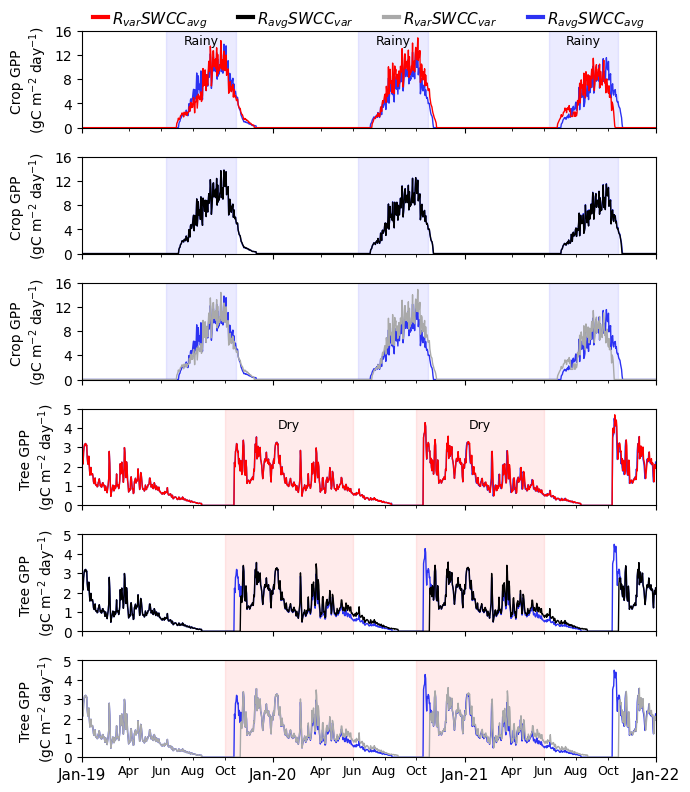

In [5]:
# Usage
file_path = r'C:\Users\ANDILATT\OneDrive\Desktop\plotSensWater.csv'
fig = plot_seasonal_data(file_path)
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, YearLocator, MonthLocator
from matplotlib.lines import Line2D
from datetime import timedelta

# Load the uploaded CSV file

def create_subplot_params():
    return {
        'fluxlat': {
            'ylabel': 'Latent Heat \n(MJ m$^{-2}$ day$^{-1}$)',
            'yticks': [0, 4, 8, 12, 16],
            'ylim': (0, 16),
            'vars': [
                ('R_avgSWCC_avg_fluxlat', 'R_varSWCC_avg_fluxlat', "#2c32f2", "red"),
                ('R_avgSWCC_avg_fluxlat', 'R_avgSWCC_var_fluxlat', "#2c32f2", "black"),                
                ('R_avgSWCC_avg_fluxlat', 'R_varSWCC_var_fluxlat', "#2c32f2", "darkgrey")
            ]
        },
        'fluxsens': {
            'ylabel': 'Sensible Heat \n(W m$^{-2}$)',
            'yticks': [0, 4, 8, 12, 16],
            'ylim': (0, 16),
            'vars': [
                ('R_avgSWCC_avg_fluxsens', 'R_varSWCC_avg_fluxsens', "#2c32f2", "red"),
                ('R_avgSWCC_avg_fluxsens', 'R_avgSWCC_var_fluxsens', "#2c32f2", "black"),
                ('R_avgSWCC_avg_fluxsens', 'R_varSWCC_var_fluxsens', "#2c32f2", "darkgrey")
            ]
        }
    }

def plot_seasonal_data_2(file_path):
    # Load and prepare data
    data = pd.read_csv(file_path)
    data['time_counter'] = pd.to_datetime(data['time_counter'], format='%m/%d/%Y %H:%M')
    
    # Create subplots
    fig, axes = plt.subplots(6, 1, figsize=(7, 8), sharex=True)
    params = create_subplot_params()
    line_weight = 1
    
    # Plot rainy seasons
    rainy_seasons = []
    for year, group in data.groupby(data['time_counter'].dt.year):
        rain_dates = group[group['Rain_avg'] > 5]['time_counter']
        if not rain_dates.empty:
            rainy_seasons.append((rain_dates.min(), rain_dates.max()- timedelta(days=22)))

    # Plot dry periods
    dry_periods = [
        (pd.Timestamp('2019-10-01'), pd.Timestamp('2020-06-10')),
        (pd.Timestamp('2020-10-01'), pd.Timestamp('2021-06-10'))
    ]
    
    # Create plots for both fluxlat and fluxsens data
    for i, (param_type, param_data) in enumerate([('fluxlat', params['fluxlat']), ('fluxsens', params['fluxsens'])]):
        offset = i * 3
        for j, (var1, var2, color1, color2) in enumerate(param_data['vars']):
            ax = axes[offset + j]
            
            # Plot data
            ax.plot(data['time_counter'], data[var1], label=var1, color=color1, lw=line_weight)
            ax.plot(data['time_counter'], data[var2], label=var2, color=color2, lw=line_weight)
            
            # Set axes properties
            ax.set_ylabel(param_data['ylabel'], fontsize=10)
            ax.set_yticks(param_data['yticks'])
            ax.set_ylim(param_data['ylim'])
            
            # Add seasonal highlights
            
            for start, end in rainy_seasons:
                ax.axvspan(start, end, color='blue', alpha=0.08)
                if param_type == "fluxlat":
                    if j == 0:
                        mid_point = start + (end - start) / 2
                        ax.text(mid_point, 14, 'Rainy', color='black', fontsize=9, ha='center')
           
            for start, end in dry_periods:
                ax.axvspan(start, end, color='red', alpha=0.08)
                if param_type == "fluxlat":
                    if j == 0:
                        mid_point = start + (end - start) / 2
                        ax.text(mid_point, 14, 'Dry', color='black', fontsize=9, ha='center')
    
    # Set x-axis properties
    ax = axes[-1]
    ax.set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'))
    ax.xaxis.set_major_locator(YearLocator())
    ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
    ax.xaxis.set_major_formatter(DateFormatter("%Y"))
    ax.xaxis.set_minor_formatter(DateFormatter("%b"))
    ax.tick_params(axis='x', which='major', labelsize=11)
    ax.tick_params(axis='x', which='minor', labelsize=9)
    # Date formatter for minor ticks
    date_form = DateFormatter("%b-%y")
    ax.xaxis.set_major_formatter(date_form)
    # Add legend
    legend_lines = [Line2D([0], [0], color=c, linewidth=3) for c in ["red", "black", "darkgrey", "#2c32f2"]]
    legend_labels = [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', 
                    r'${R_{var}SWCC_{var}}$', r'${R_{avg}SWCC_{avg}}$']
    axes[0].legend(legend_lines, legend_labels,
                  loc='upper center', ncol=4, fontsize=11, bbox_to_anchor=(0.50, 1.30),
                  frameon=False, handlelength=1, handleheight=1,
                  labelspacing=0.25, borderpad=0.0, handletextpad=0.25)
    
    plt.tight_layout()
    return fig



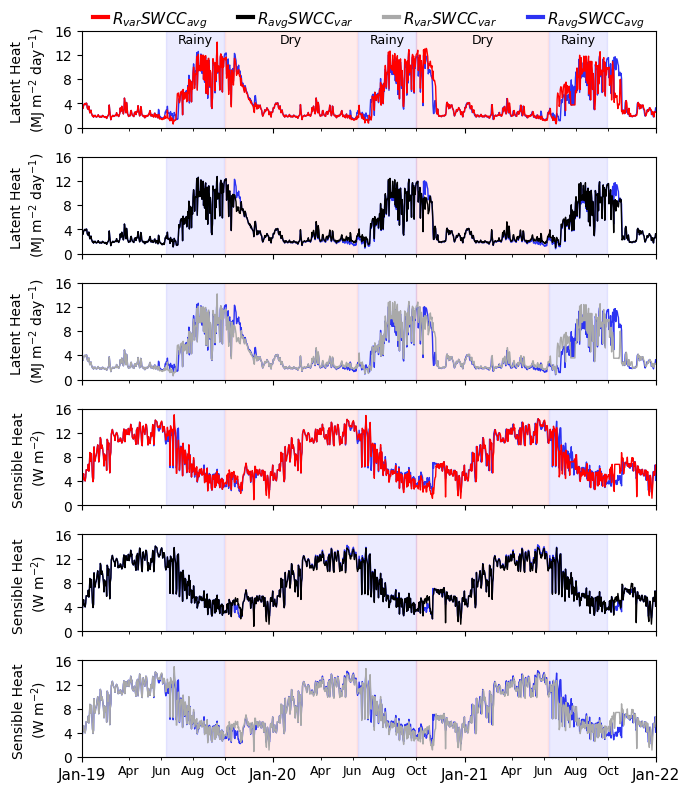

In [7]:
import matplotlib.pyplot as plt
# Load the uploaded CSV file
file_path = r'C:\Users\ANDILATT\OneDrive\Desktop\plotSensWater.csv'
fig = plot_seasonal_data_2(file_path)
plt.show()

In [3]:

# list_simulation = ["Sens.Rvar-SWCCvar", "Sens.Ravg-SWCCavg", "Sens.Rvar-SWCCavg", "Sens.Ravg-SWCCvar"]

simulation = "EXP.SIM.REF2.DENS7"
# sechiba = r"\SRF\Output\MO"
stomate = r"\SBG\Output\MO"

# sechiba_path = f"\{simulation}{sechiba}"
stomate_path = f"\{simulation}{stomate}"

import os, glob
import xarray as xr

# Construct the full path
# sechiba_path_full = os.path.join(os.getcwd(), simulation + sechiba, "*_history.nc")
# sechiba_path_full_4d = os.path.join(os.getcwd(), simulation + sechiba, "*_history_4dim.nc")

stomate_path_full = os.path.join(os.getcwd(), simulation + stomate, "*_history.nc")
# stomate_path_full_4d = os.path.join(os.getcwd(), simulation + stomate, "*_history_4dim.nc")
# Check if files exist
# files = glob.glob(sechiba_path_full)
# if not files:
# 	raise OSError("No files to open")

# Open the dataset
# sechiba_data = xr.open_mfdataset(sechiba_path_full)
# sechiba_data_4d = xr.open_mfdataset(sechiba_path_full_4d)

stomate_data = xr.open_mfdataset(stomate_path_full)
# stomate_data_4d = xr.open_mfdataset(stomate_path_full_4d)


In [ ]:
# simulation = "EXP.SIM.REF2"
# # sechiba = r"\SRF\Output\MO"
# stomate = r"\SBG\Output\MO"
# os.chdir(rf'G:\Theses\egaglo_scratch_0409\egaglo\IGCM_OUT\OL2\TEST\test\{simulation}{stomate}')

In [55]:
simulation = "Sim.WObs2.DENS26"
sechiba = r"\SRF\Output\MO"
os.chdir(rf'G:\Theses\egaglo_scratch_0409\egaglo\IGCM_OUT\OL2\TEST\test\{simulation}{sechiba}')

In [56]:
sechiba_data = xr.open_mfdataset("*_history.nc")

In [27]:
vrs = ["npp", "maxvegetfrac", "gpp", "nee", "maint_resp", "hetero_resp", "growth_resp"]


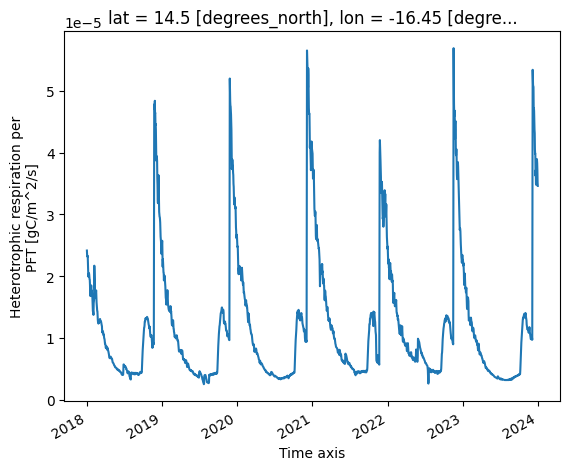

In [42]:
sechiba_data[vrs[5]].sel(veget=13).plot()

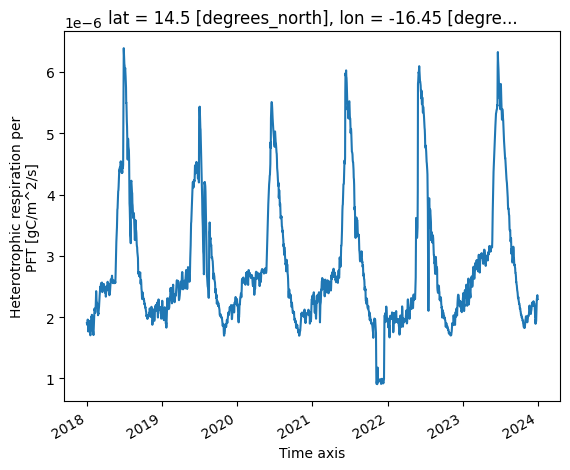

In [41]:
sechiba_data[vrs[5]].sel(veget=3).plot()

In [57]:
(0.0864000022411346*sechiba_data[["fluxsens", "fluxlat"]]).to_dataframe().to_clipboard()

In [71]:
(86400*sechiba_data.sel(veget=13).gpp).to_dataframe().to_clipboard()

In [ ]:
import pandas as pd
import numpy as np

# Liste des variables à extraire
variables_to_extract = [
    'NPP', 'GPP', 'LEAF_M_c', 'SAP_M_AB_c', 'SAP_M_BE_c', 'HEART_M_AB_c', 'HEART_M_BE_c', 
    'ROOT_M_c', 'FRUIT_M_c', 'RESERVE_M_c', 'LABILE_M_c', 'MAINT_RESP', 'GROWTH_RESP', 
    'HET_RESP', 'TOTAL_M_c', 'BM_ALLOC_LEAF_c', 
    'BM_ALLOC_SAP_AB_c', 'BM_ALLOC_SAP_BE_c', 'BM_ALLOC_ROOT_c', 'BM_ALLOC_FRUIT_c', 
    'BM_ALLOC_RES_c', 'BM_ALLOC_LABILE_c'
]

# Copier les données initiales et sélectionner le sous-ensemble dépendant de 'veget'
ds_veget = stomate_data.sel(veget=13)



In [34]:
ds_veget[variables_to_extract].to_dataframe().to_clipboard()

In [72]:
import xarray as xr
import pandas as pd


ds = sechiba_data.copy()

# Initialize a list to store metadata
metadata = []

# Loop through the variables in the dataset
for var_name, var_data in ds.data_vars.items():
    # Extract metadata attributes
    var_metadata = {
        "Variable": var_name,
        "Dimensions": str(var_data.dims),
        "Datatype": str(var_data.dtype),
        "Long Name": var_data.attrs.get("long_name", "N/A"),
        "Units": var_data.attrs.get("units", "N/A"),
        "Cell Methods": var_data.attrs.get("cell_methods", "N/A"),
        "Online Operation": var_data.attrs.get("online_operation", "N/A"),
        "Interval Operation": var_data.attrs.get("interval_operation", "N/A"),
        "Interval Write": var_data.attrs.get("interval_write", "N/A"),
    }
    metadata.append(var_metadata)

# Convert to a DataFrame
df_metadata = pd.DataFrame(metadata)



In [73]:
df_metadata.to_clipboard()

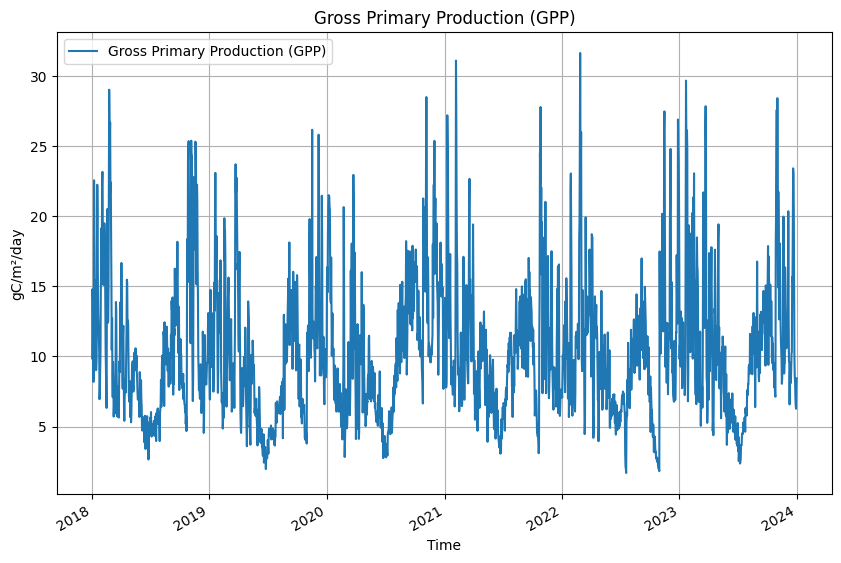

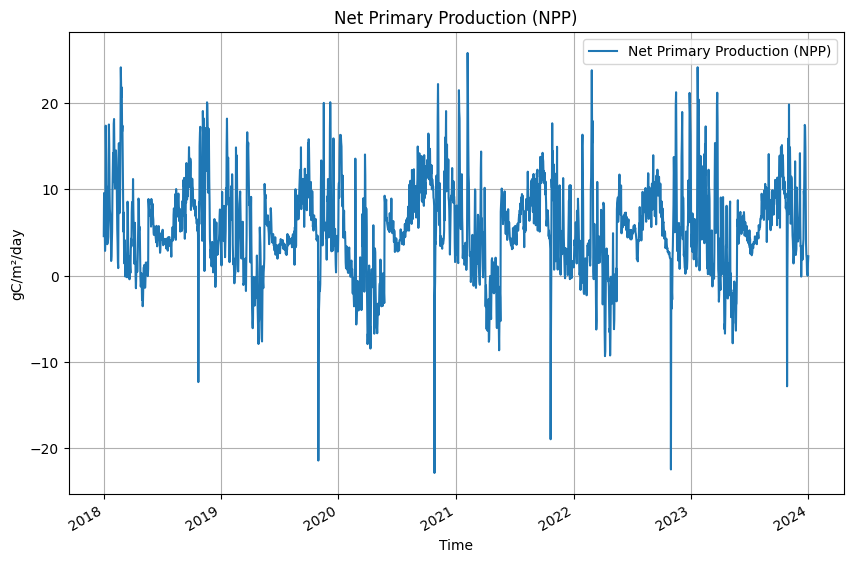

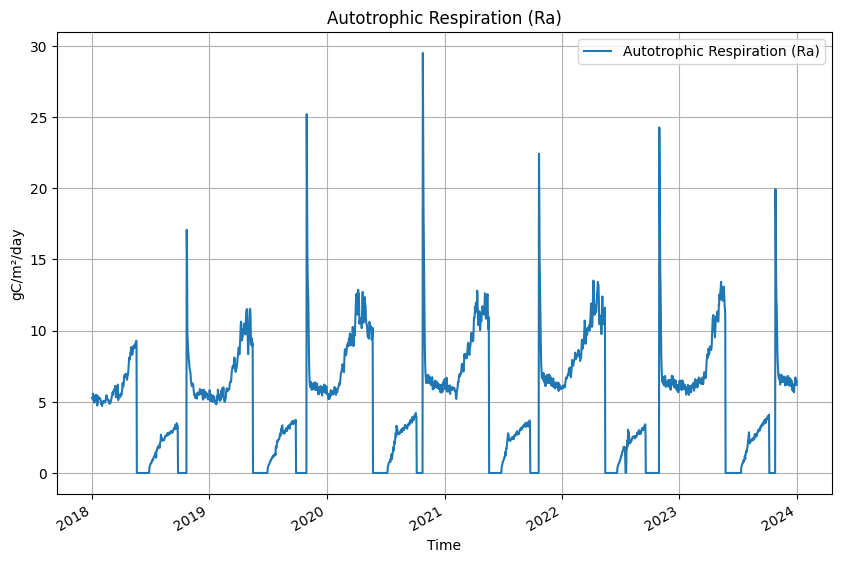

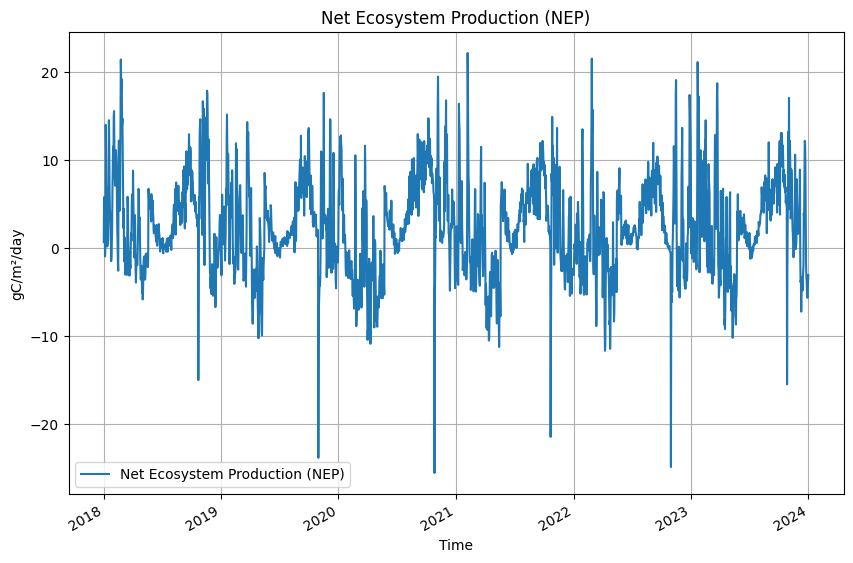

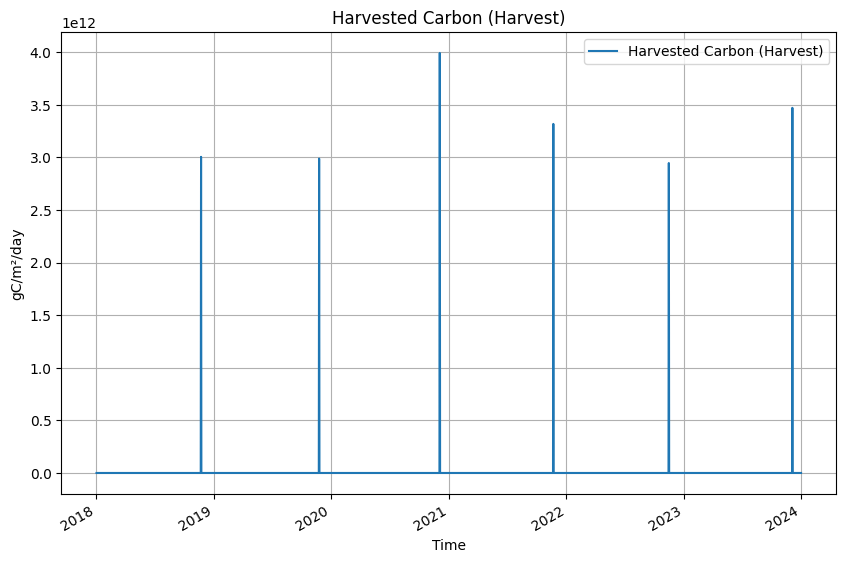

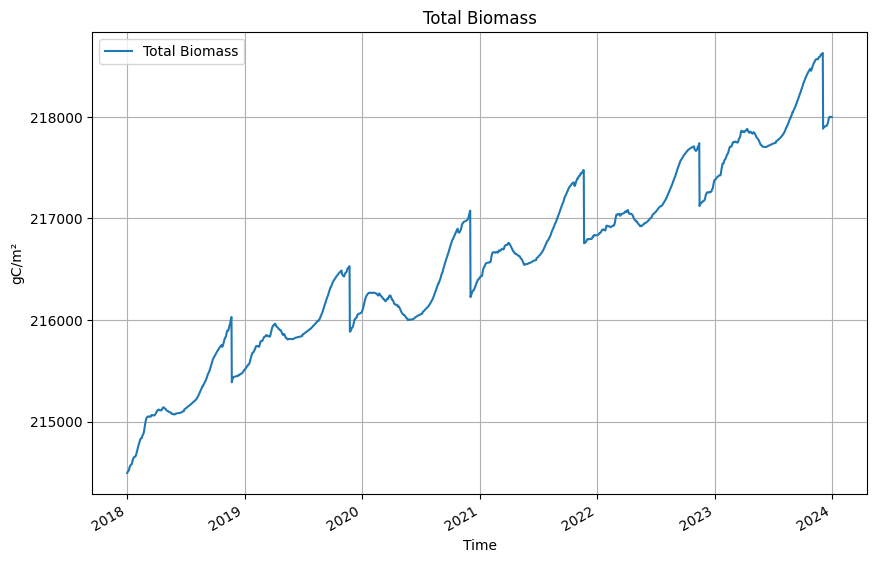

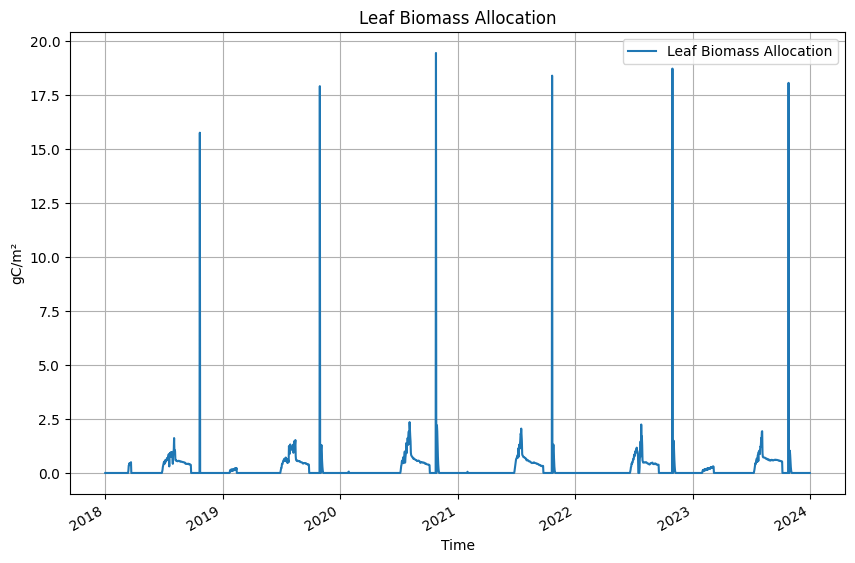

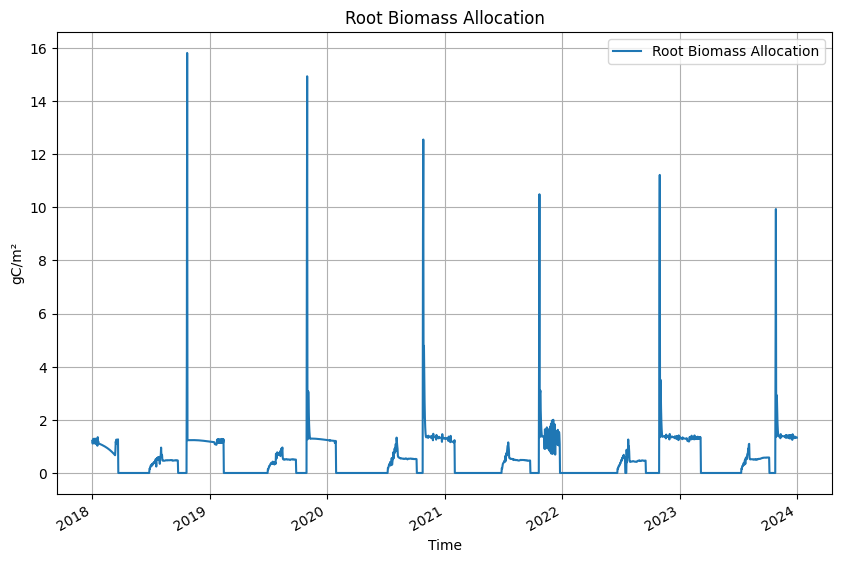

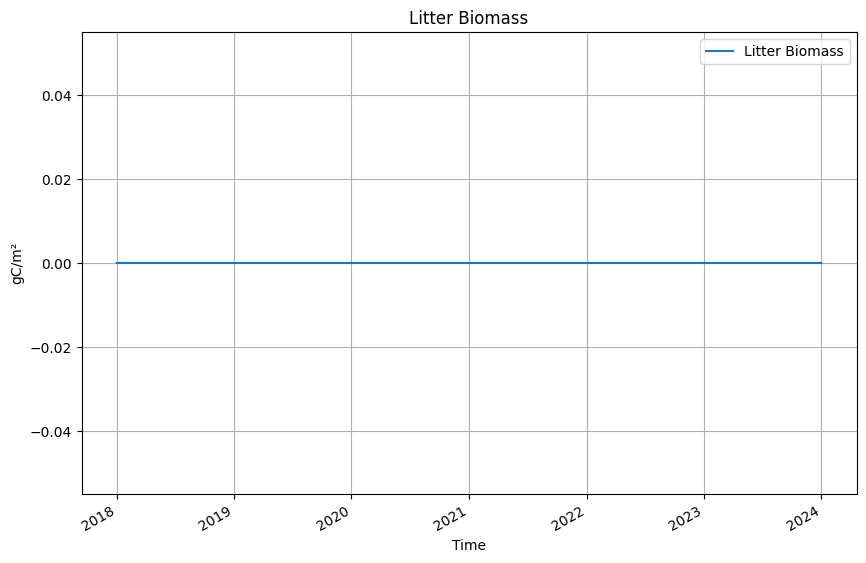

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# # Charger le fichier NetCDF
# file_path = "votre_fichier.nc"  # Remplacez par le chemin du fichier
# ds = xr.open_dataset(file_path)

# Calculs
# Composantes de la GPP
Ra = ds["MAINT_RESP"] + ds["GROWTH_RESP"]  # Autotrophic respiration
GPP = ds["NPP"] + Ra  # Gross Primary Production

# Composantes de la NPP
HET_RESP = ds["HET_RESP"]
NEP = ds["NPP"] - HET_RESP
Harvest = ds["HARVEST_TOTAL_c"]

# Biomasse et compartiments associés
Total_Biomass = ds["TOTAL_M_c"]
Leaf_Biomass = ds["BM_ALLOC_LEAF_c"]
Root_Biomass = ds["BM_ALLOC_ROOT_c"]
Litter = ds["TOTAL_BM_LITTER_c"]

# Fonctions pour tracer les courbes
def plot_variable(variable, title, ylabel, time_dim="time_counter", pft_dim="veget"):
    plt.figure(figsize=(10, 6))
    if pft_dim in variable.dims:
        variable = variable.sum(dim=pft_dim)  # Somme sur les types de végétation (si applicable)
    variable.mean(dim="lat").mean(dim="lon").plot(label=title)  # Moyenne spatiale
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Time")
    plt.legend()
    plt.grid()
    plt.show()

# Tracer les composantes de la GPP
plot_variable(GPP, "Gross Primary Production (GPP)", "gC/m²/day")
plot_variable(ds["NPP"], "Net Primary Production (NPP)", "gC/m²/day")
plot_variable(Ra, "Autotrophic Respiration (Ra)", "gC/m²/day")

# Tracer les composantes de la NPP
plot_variable(NEP, "Net Ecosystem Production (NEP)", "gC/m²/day")
plot_variable(Harvest, "Harvested Carbon (Harvest)", "gC/m²/day")

# Tracer les compartiments de biomasse
plot_variable(Total_Biomass, "Total Biomass", "gC/m²")
plot_variable(Leaf_Biomass, "Leaf Biomass Allocation", "gC/m²")
plot_variable(Root_Biomass, "Root Biomass Allocation", "gC/m²")
plot_variable(Litter, "Litter Biomass", "gC/m²")

# # Sauvegarde des courbes en PNG
# def save_plot(variable, title, ylabel, filename, time_dim="time_counter", pft_dim="veget"):
#     plt.figure(figsize=(10, 6))
#     if pft_dim in variable.dims:
#         variable = variable.sum(dim=pft_dim)  # Somme sur les types de végétation (si applicable)
#     variable.mean(dim="lat").mean(dim="lon").plot(label=title)  # Moyenne spatiale
#     plt.title(title)
#     plt.ylabel(ylabel)
#     plt.xlabel("Time")
#     plt.legend()
#     plt.grid()
#     plt.savefig(filename)
#     plt.close()

# # Exemple de sauvegarde
# save_plot(GPP, "Gross Primary Production (GPP)", "gC/m²/day", "GPP_plot.png")
# save_plot(ds["NPP"], "Net Primary Production (NPP)", "gC/m²/day", "NPP_plot.png")


In [40]:
# Copier les données initiales et sélectionner le sous-ensemble dépendant de 'veget'
ds_veget = stomate_data.sel(veget=13)

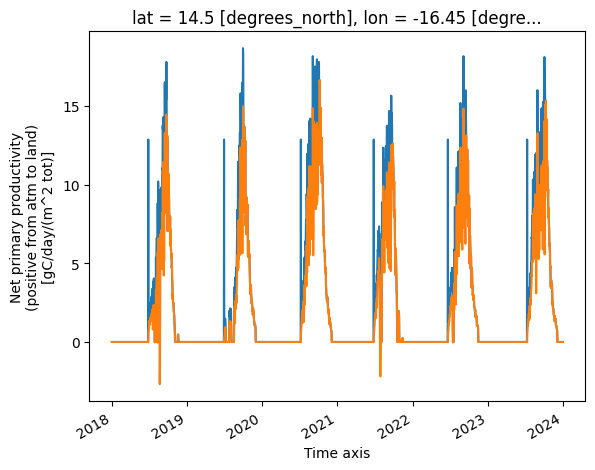

In [42]:
ds_veget["GPP"].plot()
ds_veget["NPP"].plot()

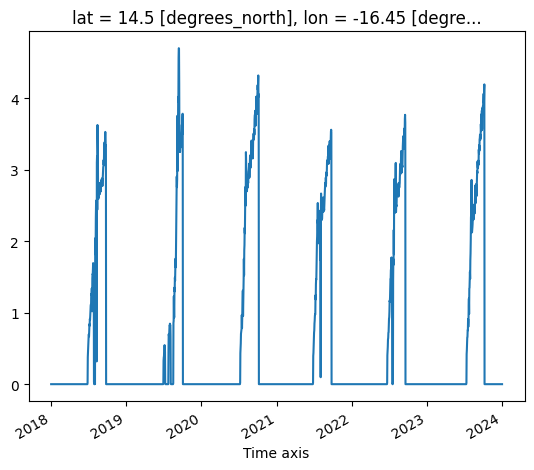

In [43]:
# Composantes de la GPP
Ra = ds_veget["MAINT_RESP"] + ds_veget["GROWTH_RESP"]  # Autotrophic respiration
Ra.plot()

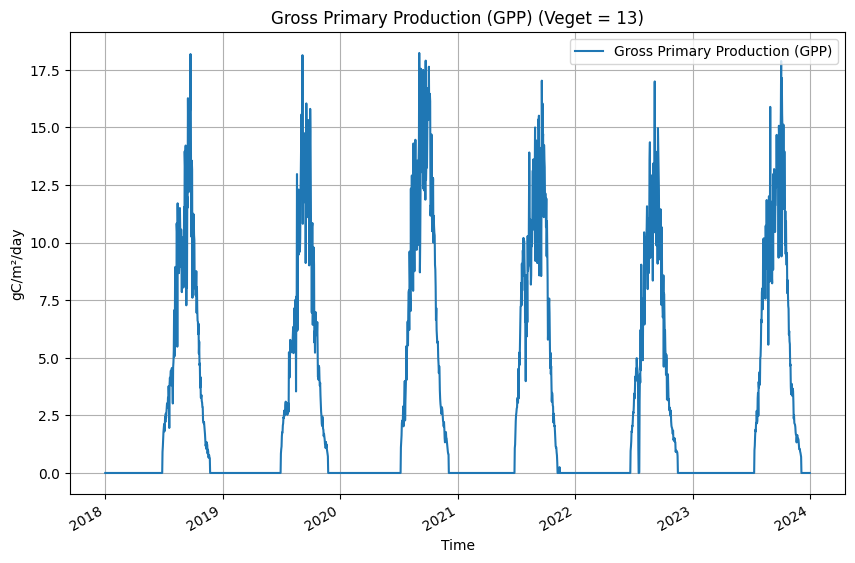

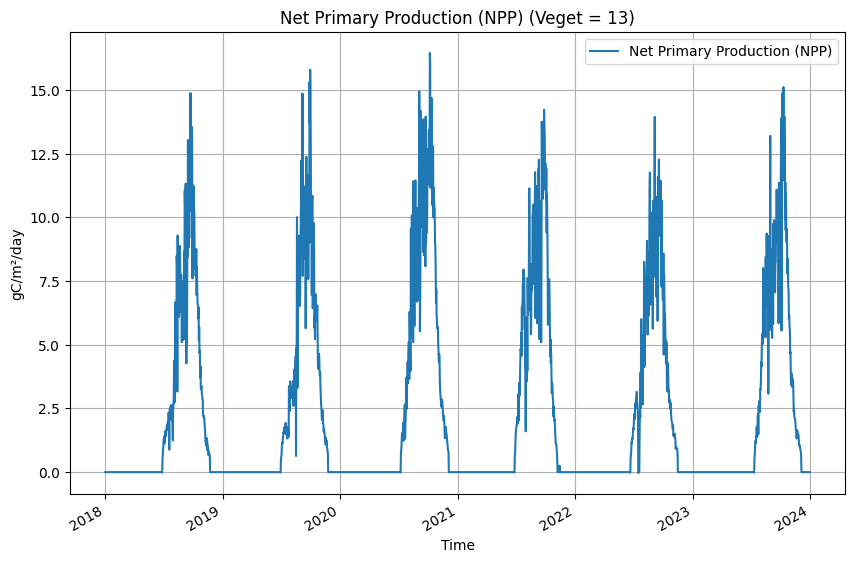

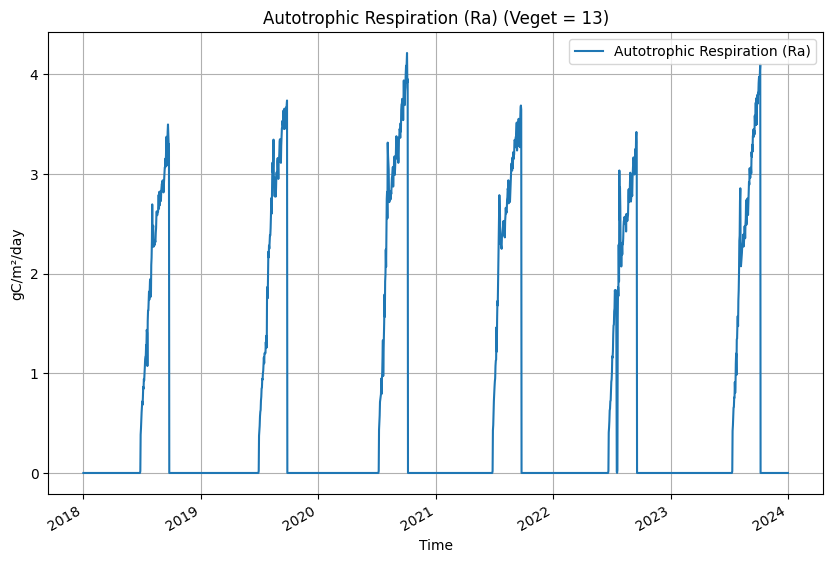

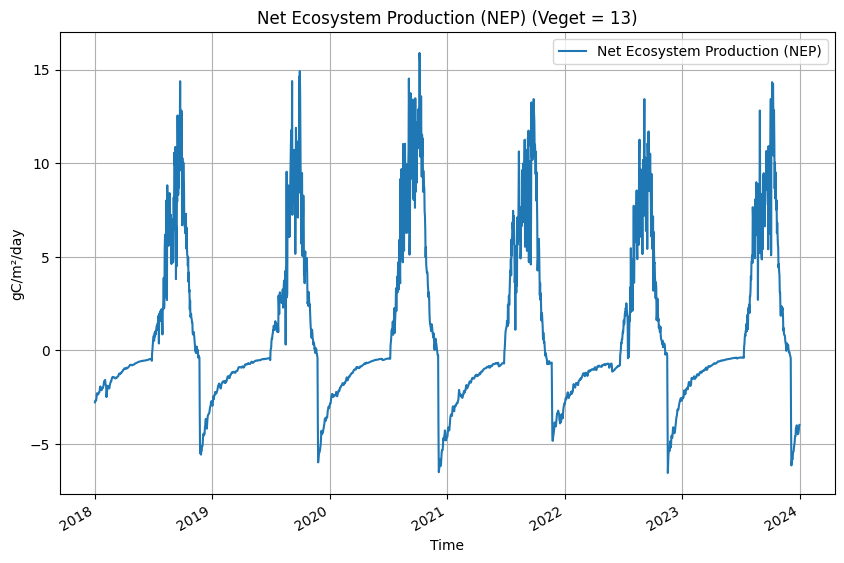

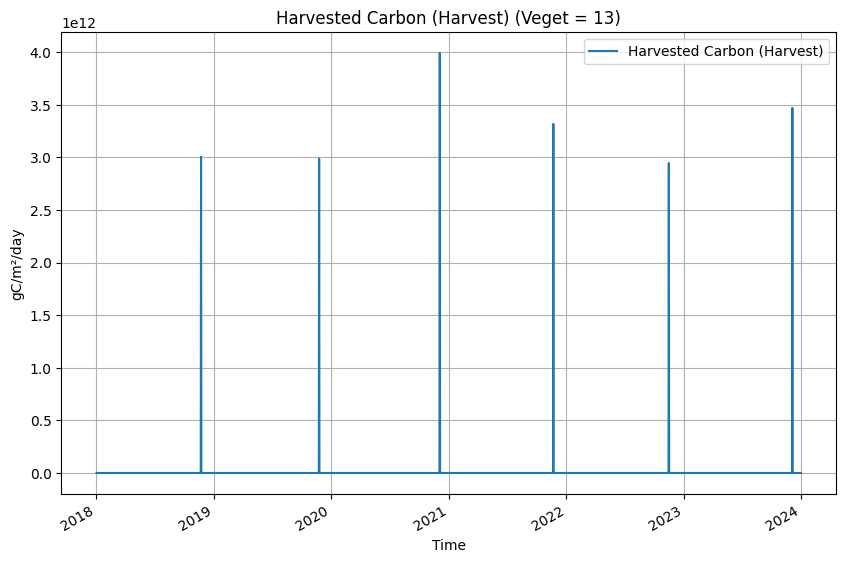

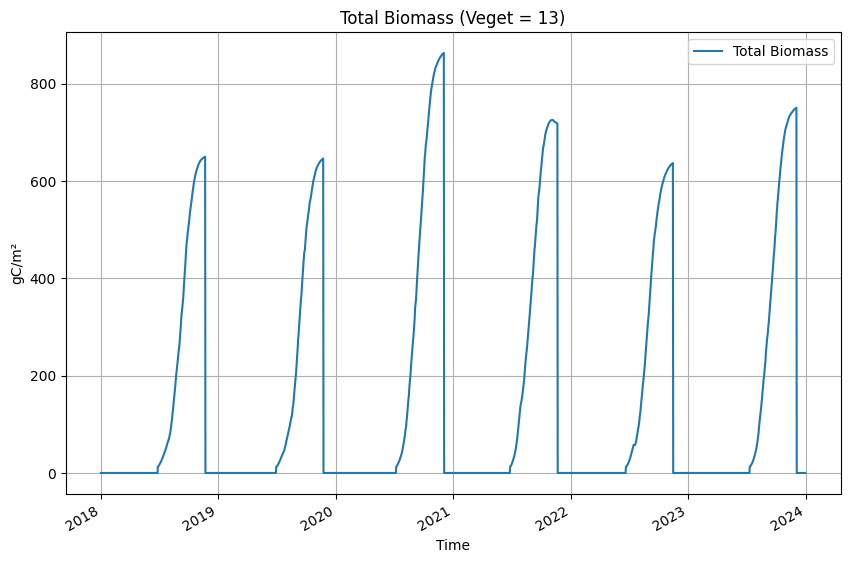

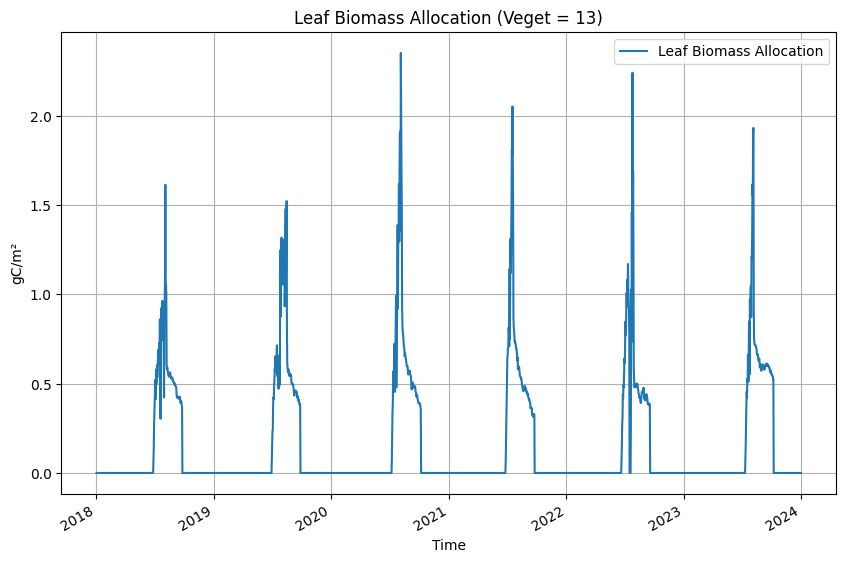

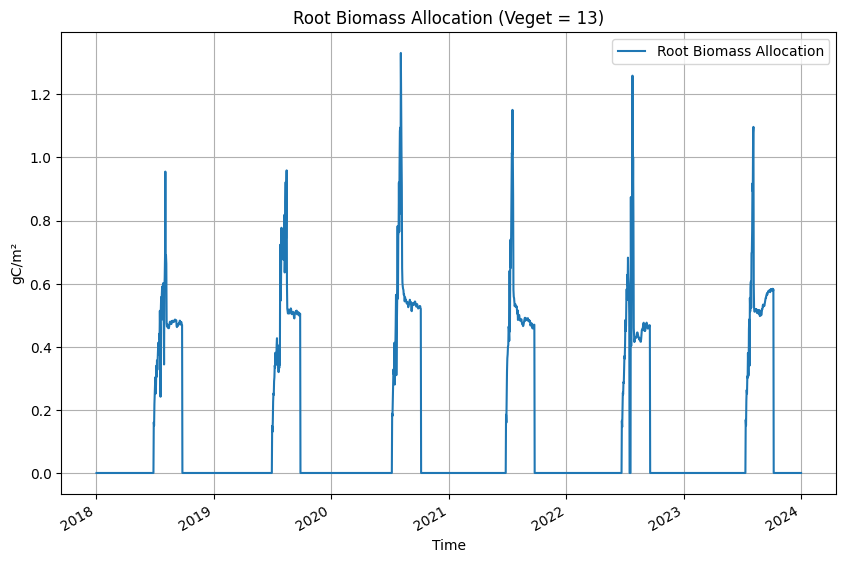

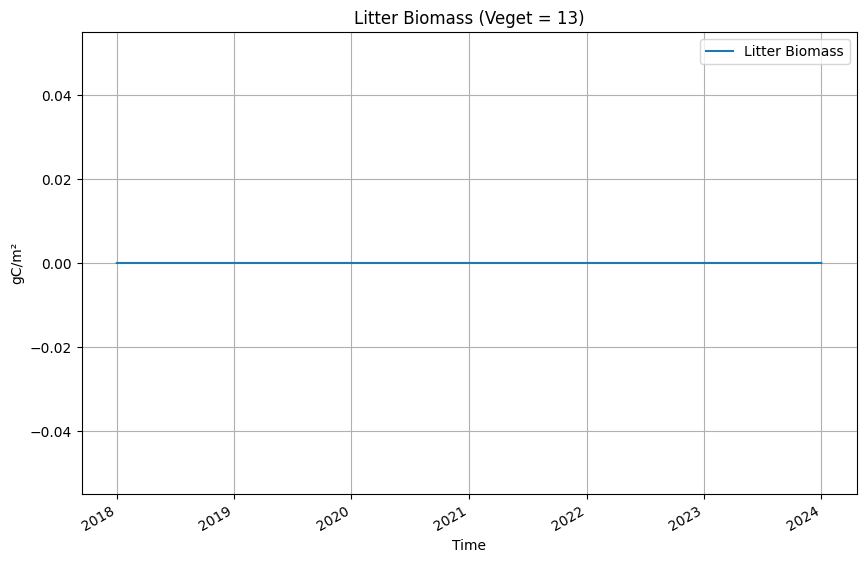

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Filtrer pour veget = 13
veget_index = 13
ds_veget = ds.sel(veget=veget_index)



# Composantes de la NPP
HET_RESP = ds_veget["HET_RESP"]
NEP = ds_veget["NPP"] - HET_RESP
Harvest = ds_veget["HARVEST_TOTAL_c"]

# Biomasse et compartiments associés
Total_Biomass = ds_veget["TOTAL_M_c"]
Leaf_Biomass = ds_veget["BM_ALLOC_LEAF_c"]
Root_Biomass = ds_veget["BM_ALLOC_ROOT_c"]
Litter = ds_veget["TOTAL_BM_LITTER_c"]

# Fonctions pour tracer les courbes
def plot_variable(variable, title, ylabel, time_dim="time_counter"):
    plt.figure(figsize=(10, 6))
    variable.mean(dim="lat").mean(dim="lon").plot(label=title)  # Moyenne spatiale
    plt.title(f"{title} (Veget = {veget_index})")
    plt.ylabel(ylabel)
    plt.xlabel("Time")
    plt.legend()
    plt.grid()
    plt.show()

# Tracer les composantes de la GPP
plot_variable(GPP, "Gross Primary Production (GPP)", "gC/m²/day")
plot_variable(ds_veget["NPP"], "Net Primary Production (NPP)", "gC/m²/day")
plot_variable(Ra, "Autotrophic Respiration (Ra)", "gC/m²/day")

# Tracer les composantes de la NPP
plot_variable(NEP, "Net Ecosystem Production (NEP)", "gC/m²/day")
plot_variable(Harvest, "Harvested Carbon (Harvest)", "gC/m²/day")

# Tracer les compartiments de biomasse
plot_variable(Total_Biomass, "Total Biomass", "gC/m²")
plot_variable(Leaf_Biomass, "Leaf Biomass Allocation", "gC/m²")
plot_variable(Root_Biomass, "Root Biomass Allocation", "gC/m²")
plot_variable(Litter, "Litter Biomass", "gC/m²")

# Sauvegarde des courbes en PNG
def save_plot(variable, title, ylabel, filename, time_dim="time_counter"):
    plt.figure(figsize=(10, 6))
    variable.mean(dim="lat").mean(dim="lon").plot(label=title)  # Moyenne spatiale
    plt.title(f"{title} (Veget = {veget_index})")
    plt.ylabel(ylabel)
    plt.xlabel("Time")
    plt.legend()
    plt.grid()
    plt.savefig(filename)
    plt.close()

# Exemple de sauvegarde
# save_plot(GPP, "Gross Primary Production (GPP)", "gC/m²/day", "GPP_plot_veget_13.png")
# save_plot(ds_veget["NPP"], "Net Primary Production (NPP)", "gC/m²/day", "NPP_plot_veget_13.png")
# save_plot(Ra, "Autotrophic Respiration (Ra)", "gC/m²/day", "Ra_plot_veget_13.png")




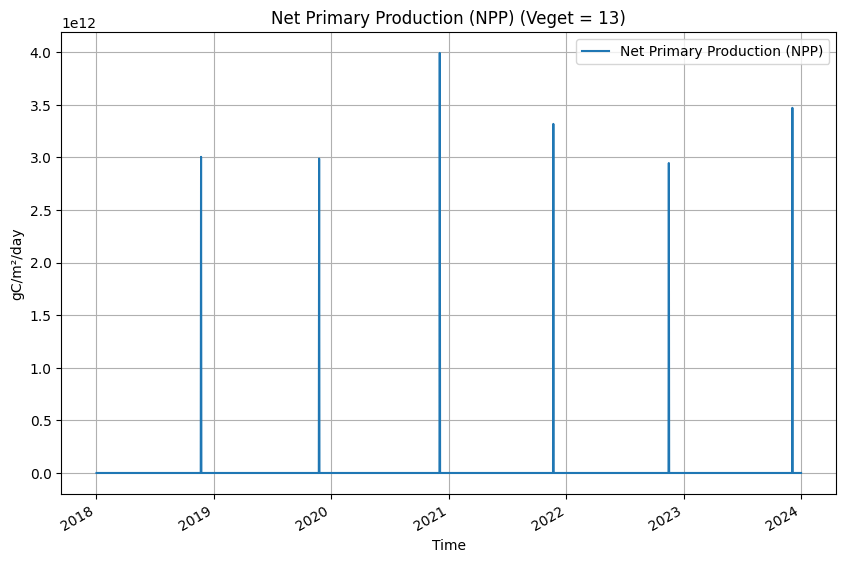

In [13]:
plot_variable(ds_veget["HARVEST_CROP_c"], "Net Primary Production (NPP)", "gC/m²/day")

In [24]:
# Données d'entrée
harvest_crop_c = 3004967400000  # gC/grid/y (valeur fournie)
resolution_degres = 1  # Exemple : résolution spatiale 1° x 1°

# Surface moyenne d'un degré carré à l'équateur (en hectares)
surface_moyenne = 12364  # hectares pour un carré de 1° x 1°

# Calcul de la surface réelle en fonction de la résolution
surface_grille = surface_moyenne * (resolution_degres ** 2)

# Conversion en gC/ha/y
harvest_crop_c_ha = harvest_crop_c / surface_grille

print(f"Harvest Crop C : {harvest_crop_c_ha:.2f} gC/ha/y")


Harvest Crop C : 243041685.54 gC/ha/y


In [21]:
lat

<xarray.DataArray 'lat' (lat: 1)>
array([14.49581], dtype=float32)
Coordinates:
  * lat      (lat) float32 14.5
Attributes:
    axis:           Y
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north

In [83]:
sechiba_data_4d.moistc.sel(soiltyp=2).isel(solay=85).to_dataframe().reset_index().to_clipboard()

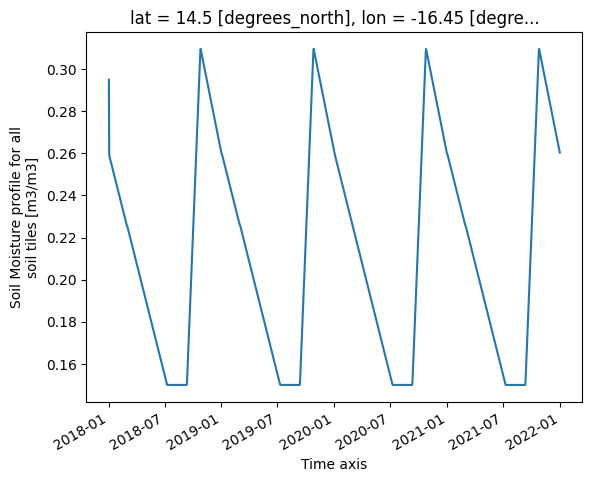

In [70]:
sechiba_data_4d.moistc.sel(soiltyp=2).isel(solay=85).plot()

In [ ]:
import os
import glob
import xarray as xr
import pandas as pd
import numpy as np

# Liste des simulations avec leurs noms raccourcis
list_simulation = ["Sens.Rvar-SWCCvar", "Sens.Ravg-SWCCavg", "Sens.Rvar-SWCCavg", "Sens.Ravg-SWCCvar"]
short_names = ["Rvar_SWCCvar", "Ravg_SWCCavg", "Rvar_SWCCavg", "Ravg_SWCCvar"]

# Constantes de conversion
CSTE_GPP = 60 * 60 * 24  # Conversion de gC/m²/s à gC/m²/jour
CSTE_FLUX = 0.0864000022411346  # Conversion de W/m² à MJ/m²/jour
I_CROP = 13  # Indice pour les cultures
I_TREE = 3  # Indice pour les arbres

# Initialiser un DataFrame pour stocker les résultats vide
all_data = pd.DataFrame()

# Parcourir chaque simulation et son nom raccourci
for index, (simulation, short_name) in enumerate(zip(list_simulation, short_names)):
    # Définir les chemins des fichiers
    sechiba_path = os.path.join(os.getcwd(), simulation, "SRF", "Output", "MO", "*_history.nc")

    # Vérifier les fichiers
    sechiba_files = glob.glob(sechiba_path)

    if not sechiba_files:
        raise OSError(f"Aucun fichier trouvé pour la simulation {simulation} dans {sechiba_path}")

    # Charger les données avec dask pour améliorer les performances
    with xr.open_mfdataset(sechiba_files, chunks={'time': 100}) as sechiba_data:
        # Récupérer les proportions des cultures et des arbres
        prop_crop = sechiba_data.maxvegetfrac.sel(veget=I_CROP).values[0, 0, 0]
        prop_tree = sechiba_data.maxvegetfrac.sel(veget=I_TREE).values[0, 0, 0]

        # Conversions avec compute() pour l'optimisation
        gpp_tree = (prop_tree * CSTE_GPP * sechiba_data.gpp.sel(veget=I_TREE)).compute()
        gpp_crop = (prop_crop * CSTE_GPP * sechiba_data.gpp.sel(veget=I_CROP)).compute()
        flux_sens = (CSTE_FLUX * sechiba_data.fluxsens).compute()
        flux_lat = (CSTE_FLUX * sechiba_data.fluxlat).compute()

    # Conversion en DataFrame
    gpp_tree_df = gpp_tree.to_dataframe().reset_index()
    gpp_crop_df = gpp_crop.to_dataframe().reset_index()
    flux_sens_df = flux_sens.to_dataframe().reset_index()
    flux_lat_df = flux_lat.to_dataframe().reset_index()

    # Renommage des colonnes
    gpp_tree_df.rename(columns={'gpp': f'gppTree_{short_name}'}, inplace=True)
    gpp_crop_df.rename(columns={'gpp': f'gppCrop_{short_name}'}, inplace=True)
    flux_sens_df.rename(columns={'fluxsens': f'fsens_{short_name}'}, inplace=True)
    flux_lat_df.rename(columns={'fluxlat': f'flat_{short_name}'}, inplace=True)

    # Suppression des colonnes inutiles
    for df in [gpp_tree_df, gpp_crop_df, flux_sens_df, flux_lat_df]:
        df.drop(columns=['time_centered', 'veget'], inplace=True, errors='ignore')

    # Fusion des données avec réduction du nombre de colonnes
    merged_data = pd.concat([gpp_tree_df, gpp_crop_df, flux_sens_df, flux_lat_df], axis=1)
    merged_data = merged_data.loc[:,~merged_data.columns.duplicated()]

    # Fusion avec le DataFrame global
    if index == 0:
        all_data = merged_data
    else:
        all_data = pd.merge(all_data, merged_data, how='outer')

# Suppression des doublons et conservation d'un seul ensemble de coordonnées
all_data = all_data.drop_duplicates(subset=["time_counter", "lat", "lon"])

# Optionnel : sauvegarde des résultats
# all_data.to_csv("simulations_results.csv", index=False)

In [84]:
all_data.to_clipboard()

In [57]:
sechiba_data.rain

<xarray.DataArray 'rain' (time_counter: 1461, lat: 1, lon: 1)>
dask.array<concatenate, shape=(1461, 1, 1), dtype=float32, chunksize=(1, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat            (lat) float32 14.5
  * lon            (lon) float32 -16.45
    time_centered  (time_counter) datetime64[ns] dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 2018-01-01T12:00:00 ... 2021...
Attributes:
    long_name:           Rainfall rate
    units:               mm/d
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 d
    cell_methods:        time: mean (interval: 1800 s)

In [56]:
a = sechiba_data.gppTree.to_dataframe().reset_index()
a["gppTree"] = a["gppTree"]*60*60*24*1000

In [12]:
(60*60*24*sechiba_data.gpp).sel(veget=3).to_dataframe().reset_index().to_clipboard()

In [57]:
a.to_clipboard()

In [4]:
clim_var = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_var\*")
clim_avg = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_avg\*")

In [ ]:
clim_avg_files = ["SN-Nkr_composite_2019-2019.nc", "SN-Nkr_composite_2020-2020.nc","SN-Nkr_composite_2021-2021.nc"]
clim_var_files = ["SN-Nkr_RainObs_2019-2019.nc", "SN-Nkr_RainObs_2020-2020.nc","SN-Nkr_RainObs_2021-2021.nc"]

In [17]:
# Liste des variables à remplacer
variables_to_replace = [
    'Tair', 'Qair', 'PSurf', 'Wind_N', 'Wind_E', 'Snowf', 'SWdown', 'LWdown',
    'tair_qc', 'qair_qc', 'psurf_qc', 'wind_n_qc', 'Wind_e_qc', 
    'Rainf_qc', 'Snowf_qc', 'SWdown_qc', 'LWdown_qc'
]

# Boucle sur chaque variable pour effectuer le remplacement
for var in variables_to_replace:
    if var in clim_var and var in clim_avg:  # Vérification si la variable existe dans les deux
        clim_avg[var] = clim_var[var]


In [ ]:
clim_var = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_var\*")
clim_avg = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_avg\*")

In [97]:
import os
import xarray as xr

# Liste des fichiers
clim_avg_files = [
    "SN-Nkr_composite_2018-2018.nc",
    "SN-Nkr_composite_2019-2019.nc",
    "SN-Nkr_composite_2020-2020.nc",
    "SN-Nkr_composite_2021-2021.nc"
]

clim_var_files = [
    "SN-Nkr_2018-2018.nc",
    "SN-Nkr_2019-2019.nc",
    "SN-Nkr_2020-2020.nc",
    "SN-Nkr_2021-2021.nc"
]

# Liste des variables à remplacer
variables_to_replace = [
    'Tair', 'Qair', 'PSurf', 'Wind_N', 'Wind_E', 'Snowf', 'SWdown', 'LWdown',
    'tair_qc', 'qair_qc', 'psurf_qc', 'wind_n_qc', 'Wind_e_qc',
    'Rainf_qc', 'Snowf_qc', 'SWdown_qc', 'LWdown_qc'
]

# Chemins des répertoires
path_var = r"G:\Theses\egaglo_scratch_0409\Rain_var\\"
path_avg = r"G:\Theses\egaglo_scratch_0409\Rain_avg\\"

# Traitement des fichiers
for clim_avg_file, clim_var_file in zip(clim_avg_files, clim_var_files):
    # Chemins complets des fichiers d'entrée
    clim_avg_path = os.path.join(path_avg, clim_avg_file)
    clim_var_path = os.path.join(path_var, clim_var_file)
    
    # Chargement des fichiers
    clim_avg = xr.open_dataset(clim_avg_path)
    clim_var = xr.open_dataset(clim_var_path)
    
    # Remplacement des variables spécifiées
    for var in variables_to_replace:
        if var in clim_var and var in clim_avg:
            clim_avg[var] = clim_var[var]
    
    # Définition des noms des fichiers de sortie (dans les dossiers sources)
    output_filename_avg = os.path.join(path_avg, clim_avg_file.replace("SN-Nkr_composite", "Nkr_Rain_avg"))
    output_filename_var = os.path.join(path_var, clim_var_file.replace("SN-Nkr", "Nkr_Rain_var"))
    
    # Sauvegarde des fichiers mis à jour
    clim_avg.to_netcdf(output_filename_avg)
    clim_var.to_netcdf(output_filename_var)
    print(f"Fichiers sauvegardés : {output_filename_avg} <===> {output_filename_var}")


Fichiers sauvegardés : G:\Theses\egaglo_scratch_0409\Rain_avg\\Nkr_Rain_avg_2018-2018.nc <===> G:\Theses\egaglo_scratch_0409\Rain_var\\Nkr_Rain_var_2018-2018.nc
Fichiers sauvegardés : G:\Theses\egaglo_scratch_0409\Rain_avg\\Nkr_Rain_avg_2019-2019.nc <===> G:\Theses\egaglo_scratch_0409\Rain_var\\Nkr_Rain_var_2019-2019.nc
Fichiers sauvegardés : G:\Theses\egaglo_scratch_0409\Rain_avg\\Nkr_Rain_avg_2020-2020.nc <===> G:\Theses\egaglo_scratch_0409\Rain_var\\Nkr_Rain_var_2020-2020.nc
Fichiers sauvegardés : G:\Theses\egaglo_scratch_0409\Rain_avg\\Nkr_Rain_avg_2021-2021.nc <===> G:\Theses\egaglo_scratch_0409\Rain_var\\Nkr_Rain_var_2021-2021.nc


In [141]:
a = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_var\\VWC_obs_GAPFILLED_Nkr_solay_full_*2017.nc")
b = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_avg\\VWC_composite_*.nc")

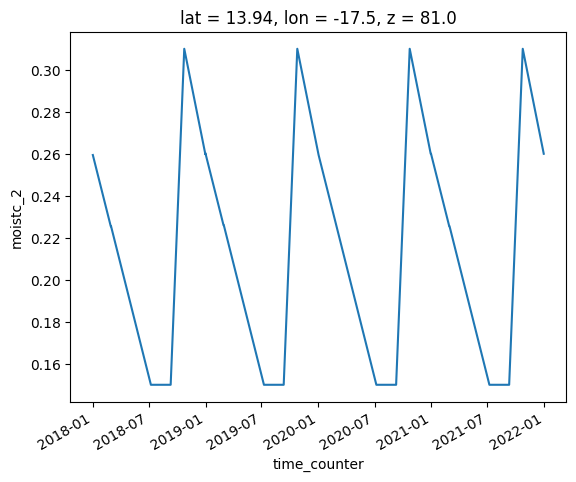

In [137]:
b.moistc_2.isel(z=80).plot()

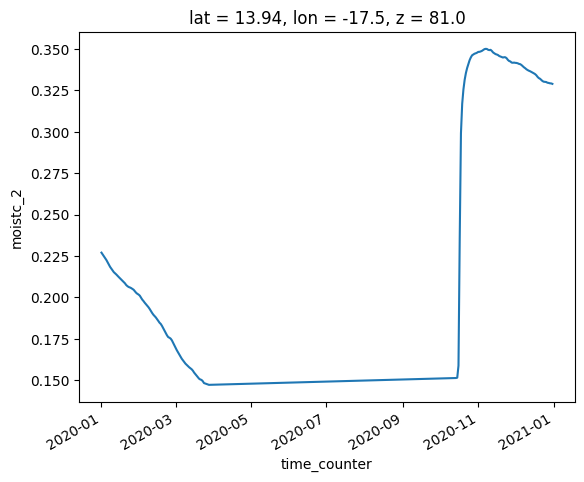

In [142]:
a.moistc_2.isel(z=80).plot()

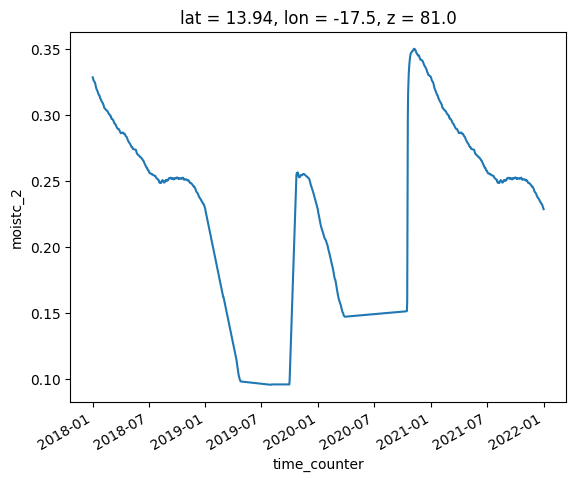

In [138]:
a.moistc_2.isel(z=80).plot()

In [133]:
# a = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_var\\SN-Nkr_2021-2021.nc")
a = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Rain_var\\VWC_obs_GAPFILLED_Nkr_solay_full_*2021.nc")

In [134]:
a

<xarray.Dataset>
Dimensions:       (time_counter: 366, z: 120, lat: 1, lon: 1)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2021-01-01 ... 2022-01-01
  * lat           (lat) float32 13.94
  * lon           (lon) float32 -17.5
  * z             (z) float32 1.0 2.0 3.0 4.0 5.0 ... 117.0 118.0 119.0 120.0
Data variables:
    moistc_1      (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_2      (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_3      (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
Attributes:
    description:  Climate Data Operators version updated to 120 layers and so...
    moistc_1:     Soil Moisture profile for soil tile 1 (m3/m3)
    moistc_2:     Soil Moisture profile for soil tile 2 (m3/m3)
    moistc_3:     Soil Moisture profile for soil tile 3 (m3/m3)

In [124]:
dataset=a
tstep_new = pd.to_datetime(dataset['time_counter'].values) - pd.DateOffset(years=3)
dataset['time_counter'] = ("time_counter", tstep_new)

In [125]:
dataset

<xarray.Dataset>
Dimensions:       (time_counter: 366, z: 120, lat: 1, lon: 1)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2018-01-01 ... 2019-01-01
  * lat           (lat) float32 13.94
  * lon           (lon) float32 -17.5
  * z             (z) float32 1.0 2.0 3.0 4.0 5.0 ... 117.0 118.0 119.0 120.0
Data variables:
    moistc_1      (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_2      (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_3      (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
Attributes:
    description:  Climate Data Operators version updated to 120 layers and so...
    moistc_1:     Soil Moisture profile for soil tile 1 (m3/m3)
    moistc_2:     Soil Moisture profile for soil tile 2 (m3/m3)
    moistc_3:     Soil Moisture profile for soil tile 3 (m3/m3)

In [3]:
a = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Test_dossier\\EXP-CompRain.CompGW_*_1M_sechiba_history.nc")
b = xr.open_mfdataset(r"G:\Theses\egaglo_scratch_0409\Test_dossier\\EXP-CompRain.CompGW.2_*_1M_sechiba_history.nc")

In [6]:
file = "Data_source_paper_biogeosciences_LATEST.xlsx"
data_water = pd.read_excel(file, sheet_name="Water_day_ano_and_percent-ano")

data_gpp = pd.read_excel(file, sheet_name="GPP_day_anomal")

data_flux = pd.read_excel(file, sheet_name="Flux_day_anomal")

# Filter data after 2018 for data_water
data_water = data_water[data_water['time_counter'].dt.year > 2018]

# Filter data after 2018 for data_gpp
data_gpp = data_gpp[data_gpp['time_counter'].dt.year > 2018]

# Filter data after 2018 for data_flux
data_flux = data_flux[data_flux['time_counter'].dt.year > 2018]


In [36]:
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def plot_anomalies(data_water, data_gpp, data_flux, simulation_short_name, monthly=False, percentage=False, save_fig=False):
    """
    Create a multi-panel plot of anomalies for different variables.
    
    Parameters:
    -----------
    data_water : pandas.DataFrame
        DataFrame containing water-related data
    data_gpp : pandas.DataFrame
        DataFrame containing GPP data
    data_flux : pandas.DataFrame
        DataFrame containing flux data
    simulation_short_name : str
        Name of the simulation to plot
    """
    def resample_monthly(df, columns, agg_method):
        """Resample a DataFrame to monthly frequency with specific aggregation methods."""
        df['time_counter'] = pd.to_datetime(df['time_counter'])
        df = df.set_index('time_counter')
        
        if isinstance(agg_method, dict):
            monthly_df = df.resample('M').agg(agg_method)
        else:
            monthly_df = df.resample('M')[columns].agg(agg_method)

        return monthly_df.reset_index()

    if monthly:
        if not percentage:
            # Resample water data (SWCC using mean, Rain using sum)
            monthly_water = resample_monthly(data_water, ['SWCC_ano', 'Rain_ano'], 
                                            agg_method={'SWCC_ano': 'mean', 'Rain_ano': 'sum'})
            
            # Resample GPP data (sum method)
            monthly_gpp = resample_monthly(data_gpp, 
                                        [f'gppTree_{simulation_short_name}_ano', 
                                            f'gppCrop_{simulation_short_name}_ano'], 
                                        agg_method='mean')
            
            # Resample flux data (mean method)
            monthly_flux = resample_monthly(data_flux, 
                                            [f'flat_{simulation_short_name}_ano', 
                                            f'fsens_{simulation_short_name}_ano'], 
                                            agg_method='mean')
            timestamp = monthly_water['time_counter']
            SWCC = monthly_water['SWCC_ano']
            Rain = monthly_water['Rain_ano']
            gppTree = monthly_gpp[f'gppTree_{simulation_short_name}_ano']
            gppCrop = monthly_gpp[f'gppCrop_{simulation_short_name}_ano']
            flat = monthly_flux[f'flat_{simulation_short_name}_ano']
            fsens = monthly_flux[f'fsens_{simulation_short_name}_ano']
        else:
            
            # Resample water data (SWCC using mean, Rain using sum)
            monthly_water = resample_monthly(data_water, ['SWCC_%ano', 'Rain_ano', 'Ravg'], 
                                            agg_method={'SWCC_%ano': 'mean', 'Rain_ano': 'sum',
                                                        'Ravg': 'sum'})
            
            # Resample GPP data (sum method)
            monthly_gpp = resample_monthly(data_gpp, 
                                        [f'gppTree_{simulation_short_name}_%ano', 
                                            f'gppCrop_{simulation_short_name}_%ano'], 
                                        agg_method='mean')
            
            # Resample flux data (mean method)
            monthly_flux = resample_monthly(data_flux, 
                                            [f'flat_{simulation_short_name}_%ano', 
                                            f'fsens_{simulation_short_name}_%ano'], 
                                            agg_method='mean')

            timestamp = monthly_water['time_counter']
            SWCC = monthly_water['SWCC_%ano']
            Rain = np.where(monthly_water["Ravg"] == 0, 0,
                            100 * (monthly_water['Rain_ano']) / monthly_water["Ravg"]
                            )
            gppTree = monthly_gpp[f'gppTree_{simulation_short_name}_%ano']
            gppCrop = monthly_gpp[f'gppCrop_{simulation_short_name}_%ano']
            flat = monthly_flux[f'flat_{simulation_short_name}_%ano']
            fsens = monthly_flux[f'fsens_{simulation_short_name}_%ano']               
    else:
        # Extract anomaly data dynamically based on simulation name
        timestamp = data_water['time_counter']
        SWCC = data_water['SWCC_ano']
        Rain = data_water['Rain_ano']
        gppTree = data_gpp[f'gppTree_{simulation_short_name}_ano']
        gppCrop = data_gpp[f'gppCrop_{simulation_short_name}_ano']
        flat = data_flux[f'flat_{simulation_short_name}_ano']
        fsens = data_flux[f'fsens_{simulation_short_name}_ano']
    
    # Set up subplots with improved spacing and layout
    if simulation_short_name.count("var") == 2:
        fig, axs = plt.subplots(5, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 1, 1]})
    else:
        fig, axs = plt.subplots(4, 1, figsize=(7, 7), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 1]})
    
    plt.subplots_adjust(hspace=0.3)
    
    # Définition des plages de dates pour axvspan
    years = pd.to_datetime(timestamp).dt.year.unique()
    for year in years:
        # Période des cultures (juillet à septembre)
        crop_start = pd.Timestamp(f"{year}-07-01")
        crop_end = pd.Timestamp(f"{year}-09-30")
        # Période des arbres (octobre de l'année n à juin de l'année n+1)
        tree_start = pd.Timestamp(f"{year}-10-01")
        tree_end = pd.Timestamp(f"{year+1}-06-30")

        for i_, ax in enumerate(axs):
            # Ajout des bandes pour les cultures avec label "Rainy"
            ax.axvspan(crop_start, crop_end, color='blue', alpha=0.1)
            ax.axvspan(tree_start, tree_end, color='red', alpha=0.1)
            if i_ == 0 :
                if "SWCCvar" in simulation_short_name:
                    axs[0].text(crop_start + (crop_end - crop_start) / 2, 75 if percentage else 0.13, 
                        "Rainy", ha='center', color='black', fontsize=8) 
                    if tree_end.year > years[-1]:
                        axs[0].text(tree_start + pd.DateOffset(days=45), 75 if percentage else 0.13, 
                                "Dry", ha='center', color='black', fontsize=8)
                    else:
                        axs[0].text(tree_start + (tree_end - tree_start) / 2, 75 if percentage else 0.13, 
                                "Dry", ha='center', color='black', fontsize=8)
                else:
                    axs[0].text(crop_start + (crop_end - crop_start) / 2, 300 if percentage else 60, 
                        "Rainy", ha='center', color='black', fontsize=8) 
                    if tree_end.year > years[-1]:
                        axs[0].text(tree_start + pd.DateOffset(days=45), 300 if percentage else 60, 
                                "Dry", ha='center', color='black', fontsize=8)
                    else:
                        axs[0].text(tree_start + (tree_end - tree_start) / 2, 300 if percentage else 60, 
                                "Dry", ha='center', color='black', fontsize=8)
    # Plot SWCC anomalies
    if "SWCCavg" in simulation_short_name:
          # Rain Anomaly Plot (Bar Plot)
        axs[0].bar(timestamp, Rain, color='blue', width=4)
        axs[0].set_ylabel(f'Rain \nanomaly \n({"%" if percentage else "mm"})')
        axs[0].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[0].set_yticks([-150, -75, 0, 75, 150, 250, 350] if percentage else [-50, -25, 0, 25, 50, 75])
        axs[0].set_ylim((-150, 350) if percentage else (-50, 75))
        
        # Crop GPP Anomaly Plot
        axs[1].plot(timestamp, gppCrop, color='black')
        axs[1].set_ylabel(f'Crop GPP \nanomaly \n({"%" if percentage else "gC m$^{-2}$ day$^{-1}$"})')
        axs[1].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        
            # Dynamically set y-ticks for Crop GPP if not all zeros
        if gppCrop.min() != 0 and gppCrop.max() != 0:
            axs[1].set_yticks([-100, -50, 0, 50, 100] if percentage else [-4, -2, 0, 2, 4])
            axs[1].set_ylim((-100, 100) if percentage else (-4, 4))
        
        # Tree GPP Anomaly Plot
        axs[2].plot(timestamp, gppTree, color='black')
        axs[2].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[2].set_ylabel(f'Tree GPP \nanomaly \n({"%" if percentage else "gC m$^{-2}$ day$^{-1}$"})')
        
            # Dynamically set y-ticks for Tree GPP if not all zeros
        if gppTree.min() != 0 and gppTree.max() != 0:
            axs[2].set_yticks([-0.25, -0.1, 0., 0.10])
            axs[2].set_ylim(-0.25, 0.10)     
         
        # Energy Flux Anomaly Plot
        axs[3].plot(timestamp, flat, color='black', label='Latent')
        axs[3].plot(timestamp, fsens, color='darkgrey', label='Sensible')
        axs[3].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[3].set_ylabel(f'Energy flux \nanomaly \n({"%" if percentage else "MJ m$^{-2}$ day$^{-1}$"})')
        
        # Legend for Energy Flux Plot
        axs[3].legend(frameon=False, loc='lower left', 
                    handlelength=1, handleheight=0.5, 
                    labelspacing=0.03, borderpad=0.0, 
                    handletextpad=0.5)
        
        # X-axis Formatting
        axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        axs[3].xaxis.set_major_locator(YearLocator())
        axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
        axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
        axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
        axs[3].tick_params(axis='y', labelsize=10)
        axs[3].tick_params(axis='x', which='major', labelsize=11)
        axs[3].tick_params(axis='x', which='minor', labelsize=9)

        # Date formatter for ticks
        date_form = DateFormatter("%b-%y")
        axs[3].xaxis.set_major_formatter(date_form)
        axs[3].set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'))
        
        # Energy Flux y-axis
        if flat.min() > -1 and flat.max() < 1:
            axs[3].set_yticks([-1, -0.5, 0, 0.5, 1])
            axs[3].set_ylim(-1, 1)
        else:
            axs[3].set_yticks([-60, -30, 0, 30, 60] if percentage else [-5, -2.5, 0, 2.5, 5])
            axs[3].set_ylim((-60, 60) if percentage else (-5, 5))
        
        # Subplot labels
        for i, label in enumerate(['(a)', '(b)', '(c)', '(d)']):
            axs[i].text(0.02, 0.75 if i == 1 else 0.8, label, 
                        transform=axs[i].transAxes, size=12, weight='bold') 
            
    elif "Ravg" in simulation_short_name:
        axs[0].plot(timestamp, SWCC, color='blue', lw=1)
        axs[0].set_ylabel(f'SWCC \nanomaly \n({"%" if percentage else "m$^{3}$ m$^{-3}$"})')
        axs[0].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[0].set_yticks([-50, -25, 0., 25, 50, 75, 100] if percentage else [-0.20, -0.10, 0., 0.10, 0.20])
        axs[0].set_ylim((-50, 100) if percentage else (-0.20, 0.20))
        
        # Tree GPP Anomaly Plot
        axs[1].plot(timestamp, gppTree, color='black')
        axs[1].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[1].set_ylabel(f'Tree GPP \nanomaly \n({"%" if percentage else "gC m$^{-2}$ day$^{-1}$"})')
        
            # Dynamically set y-ticks for Tree GPP if not all zeros
        if gppTree.min() != 0 and gppTree.max() != 0:
            axs[1].set_yticks([-110, -55, 0., 55, 110, 165] if percentage else [-0.75, -0.50, -0.25, 0., 0.15])
            axs[1].set_ylim((-110, 165) if percentage else (-0.75, 0.15))
            
        # Crop GPP Anomaly Plot
        axs[2].plot(timestamp, gppCrop, color='black')
        axs[2].set_ylabel(f'Crop GPP \nanomaly \n({"%" if percentage else "gC m$^{-2}$ day$^{-1}$"})')
        axs[2].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        
            # Dynamically set y-ticks for Crop GPP if not all zeros
        if gppCrop.min() != 0 and gppCrop.max() != 0:
            axs[2].set_yticks([-4, -2, 0, 2, 4])
            axs[2].set_ylim(-4, 4)
        
        # Energy Flux Anomaly Plot
        axs[3].plot(timestamp, flat, color='black', label='Latent')
        axs[3].plot(timestamp, fsens, color='darkgrey', label='Sensible')
        axs[3].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[3].set_ylabel(f'Energy flux \nanomaly \n({"%" if percentage else "MJ m$^{-2}$ day$^{-1}$"})')
        
        # Legend for Energy Flux Plot
        axs[3].legend(frameon=False, loc='lower left', 
                    handlelength=1, handleheight=0.5, 
                    labelspacing=0.03, borderpad=0.0, 
                    handletextpad=0.5)
        
        # X-axis Formatting
        axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        axs[3].xaxis.set_major_locator(YearLocator())
        axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
        axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
        axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
        axs[3].tick_params(axis='y', labelsize=10)
        axs[3].tick_params(axis='x', which='major', labelsize=11)
        axs[3].tick_params(axis='x', which='minor', labelsize=9)

        # Date formatter for ticks
        date_form = DateFormatter("%b-%y")
        axs[3].xaxis.set_major_formatter(date_form)
        axs[3].set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'))
        
        # Energy Flux y-axis
        if flat.min() > -1 and flat.max() < 1:
            axs[3].set_yticks([-1, -0.5, 0, 0.5, 1])
            axs[3].set_ylim(-1, 1)
        else:
            axs[3].set_yticks([-60, -30, 0, 30, 60] if percentage else [-3., -2.25, -1.50, -0.75, 0, 0.75, 1.5])
            axs[3].set_ylim((-60, 60) if percentage else (-3, 1.5))
        
        # Subplot labels
        for i, label in enumerate(['(a)', '(b)', '(c)', '(d)']):
            axs[i].text(0.02, 0.65 if i == 1 else 0.8, label, 
                        transform=axs[i].transAxes, size=12, weight='bold') 
    else:
        # SWCC Anomaly Plot
        axs[0].plot(timestamp, SWCC, color='blue', lw=1)
        axs[0].set_ylabel(f'SWCC \nanomaly \n({"%" if percentage else "m$^{3}$ m$^{-3}$"})')
        axs[0].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[0].set_yticks([-50, -25, 0., 25, 50, 75, 100] if percentage else [-0.20, -0.10, 0., 0.10, 0.20])
        axs[0].set_ylim((-50, 100) if percentage else (-0.20, 0.20))
        
        # Tree GPP Anomaly Plot
        axs[1].plot(timestamp, gppTree, color='black')
        axs[1].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[1].set_ylabel(f'Tree GPP \nanomaly \n({"%" if percentage else "gC m$^{-2}$ day$^{-1}$"})')
        
        # Dynamically set y-ticks for Tree GPP if not all zeros
        if gppTree.min() != 0 and gppTree.max() != 0:
            axs[1].set_yticks([-110, -55, 0., 55, 110, 165] if percentage else [-0.75, -0.50, -0.25, 0., 0.15])
            axs[1].set_ylim((-110, 165) if percentage else (-0.75, 0.15))
            
        # Rain Anomaly Plot (Bar Plot)
        axs[2].bar(timestamp, Rain, color='blue', width=4)
        axs[2].set_ylabel(f'Rain \nanomaly \n({"%" if percentage else "mm"})')
        axs[2].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[2].set_yticks([-150, -75, 0, 75, 150, 250, 350] if percentage else [-50, -25, 0, 25, 50, 75])
        axs[2].set_ylim((-150, 350) if percentage else (-50, 75))
        
        # Crop GPP Anomaly Plot
        axs[3].plot(timestamp, gppCrop, color='black')
        axs[3].set_ylabel(f'Crop GPP \nanomaly \n({"%" if percentage else "gC m$^{-2}$ day$^{-1}$"})')
        axs[3].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        
        # Dynamically set y-ticks for Crop GPP if not all zeros
        if gppCrop.min() != 0 and gppCrop.max() != 0:
            axs[3].set_yticks([-100, -50, 0, 50, 100] if percentage else [-4, -2, 0, 2, 4])
            axs[3].set_ylim((-100, 100) if percentage else (-4, 4))
        
        # Energy Flux Anomaly Plot
        axs[4].plot(timestamp, flat, color='black', label='Latent')
        axs[4].plot(timestamp, fsens, color='darkgrey', label='Sensible')
        axs[4].axhline(0, color='black', linestyle='-', lw=1, alpha=0.8)
        axs[4].set_ylabel(f'Energy flux \nanomaly \n({"%" if percentage else "MJ m$^{-2}$ day$^{-1}$"})')
        
        # Legend for Energy Flux Plot
        axs[4].legend(frameon=False, loc='lower left', 
                    handlelength=1, handleheight=0.5, 
                    labelspacing=0.03, borderpad=0.0, 
                    handletextpad=0.5)
        
        # X-axis Formatting
        axs[4].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        axs[4].xaxis.set_major_locator(YearLocator())
        axs[4].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
        axs[4].xaxis.set_major_formatter(DateFormatter("%Y"))
        axs[4].xaxis.set_minor_formatter(DateFormatter("%b"))
        axs[4].tick_params(axis='y', labelsize=10)
        axs[4].tick_params(axis='x', which='major', labelsize=11)
        axs[4].tick_params(axis='x', which='minor', labelsize=9)

        # Date formatter for ticks
        date_form = DateFormatter("%b-%y")
        axs[4].xaxis.set_major_formatter(date_form)
        axs[4].set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-01-01'))
        
        # Energy Flux y-axis
        if flat.min() > -1 and flat.max() < 1:
            axs[4].set_yticks([-1, -0.5, 0, 0.5, 1])
            axs[4].set_ylim(-1, 1)
        else:
            axs[4].set_yticks([-60, -30, 0, 30, 60] if percentage else [-5, -2.5, 0, 2.5, 5])
            axs[4].set_ylim((-60, 60) if percentage else (-5, 5))
    
        # Subplot labels
        for i, label in enumerate(['(a)', '(b)', '(c)', '(d)', '(e)']):
            axs[i].text(0.02, 0.65 if i == 1 else 0.8, label, 
                        transform=axs[i].transAxes, size=12, weight='bold')

    fig.suptitle(f"{'Monthly_plot_anomalies' if monthly else 'Daily_plot_anomalies'} {simulation_short_name}")
    # Adjust layout and display
    plt.tight_layout()
        # Save figure if requested
    if save_fig:
        filename = f"{'Monthly_plot_anomalies' if monthly else 'Daily_plot_anomalies'}_{simulation_short_name}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Figure saved as: {filename}")
    plt.show()


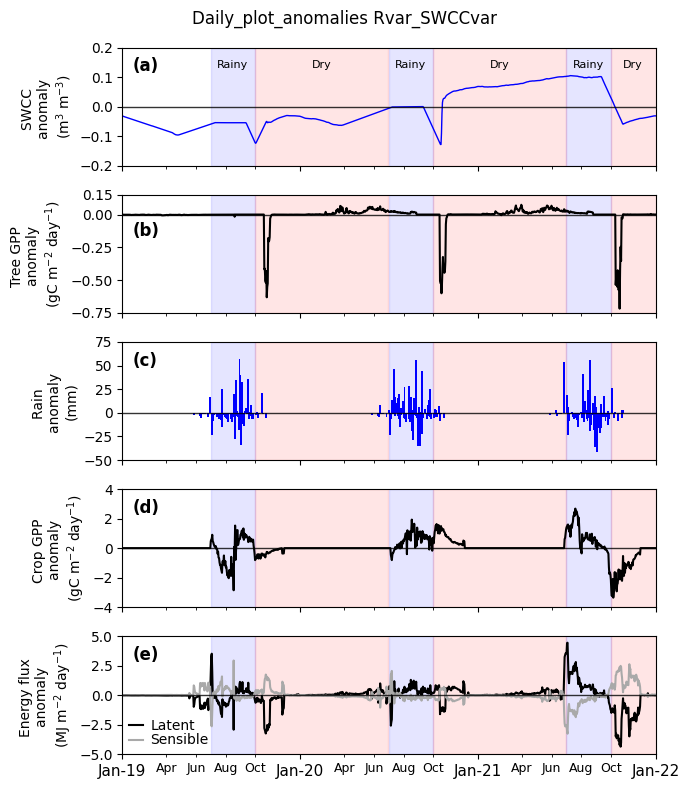

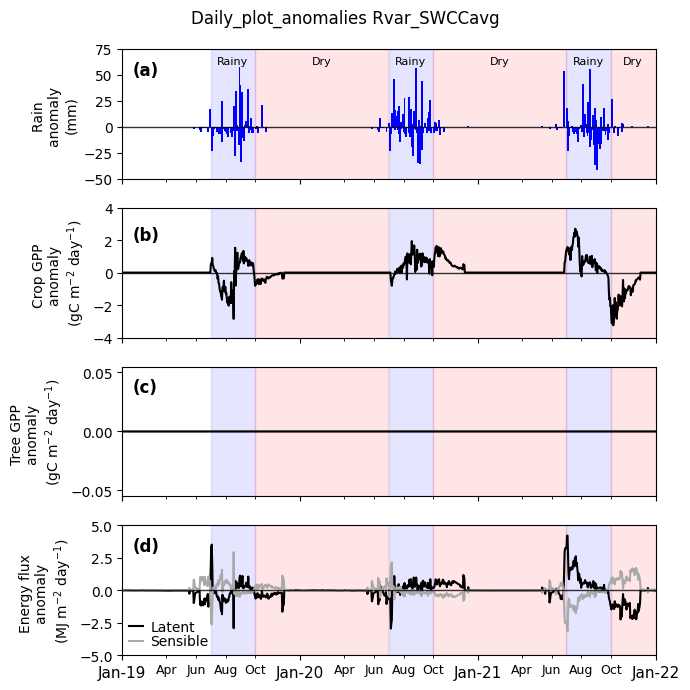

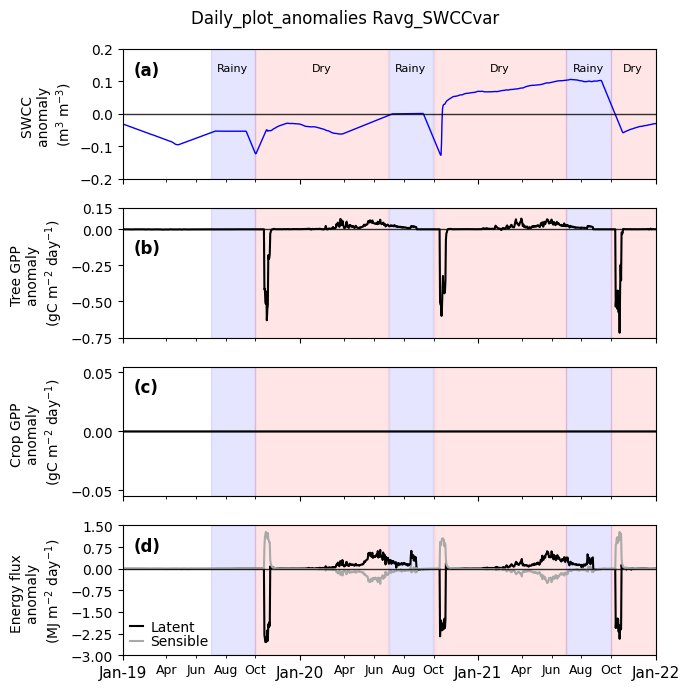

In [37]:
### save figs
short_names = ["Rvar_SWCCvar", "Rvar_SWCCavg", "Ravg_SWCCvar"]
is_save = False
for sn in short_names:

    plot_anomalies(data_water, data_gpp, data_flux, sn, monthly=False, percentage=False, save_fig=is_save)

### Anomalies en pourcentage

In [17]:
file = "Data_source_paper_biogeosciences_LATEST.xlsx"
data_water_perc = pd.read_excel(file, sheet_name="Water_day_ano_and_percent-ano")

data_gpp_perc = pd.read_excel(file, sheet_name="GPP_day_percent-ano")

data_flux_perc = pd.read_excel(file, sheet_name="Flux_day_percent-ano")

# Filter data after 2018 for data_water
data_water_perc = data_water_perc[data_water_perc['time_counter'].dt.year > 2018]

# Filter data after 2018 for data_gpp
data_gpp_perc = data_gpp_perc[data_gpp_perc['time_counter'].dt.year > 2018]

# Filter data after 2018 for data_flux
data_flux_perc = data_flux_perc[data_flux_perc['time_counter'].dt.year > 2018]


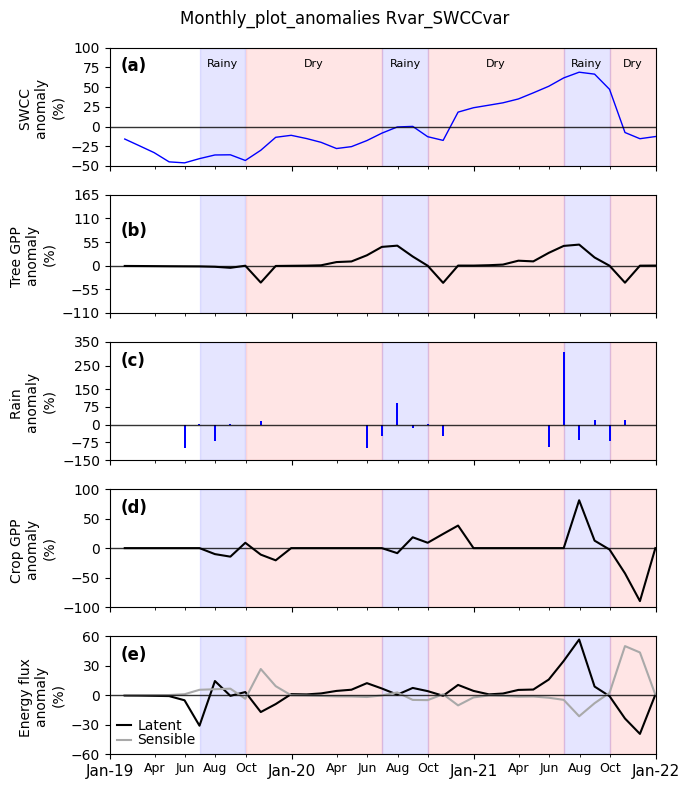

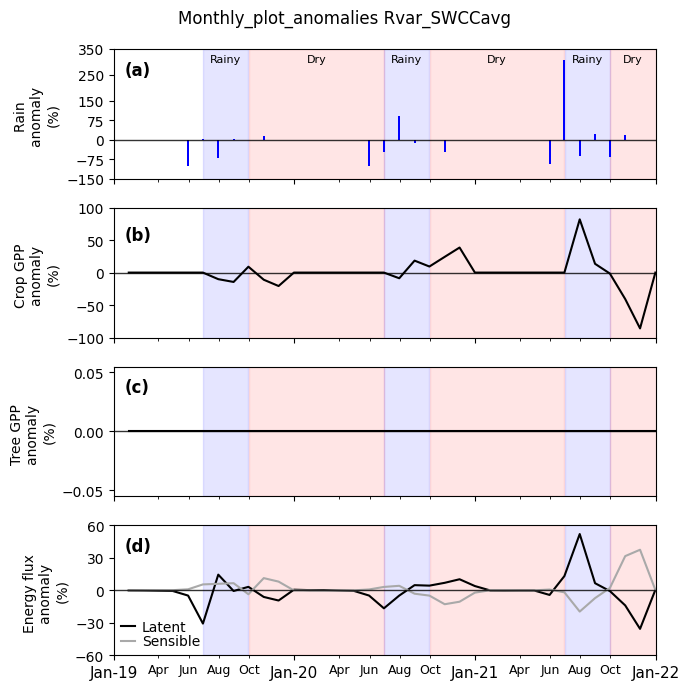

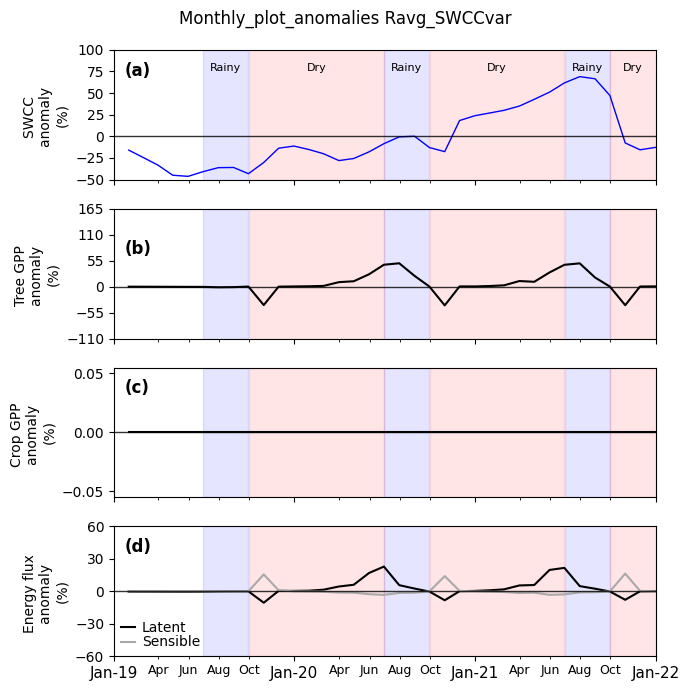

In [38]:
### save figs
short_names = ["Rvar_SWCCvar", "Rvar_SWCCavg", "Ravg_SWCCvar"]
is_save = False
for sn in short_names:

    plot_anomalies(data_water_perc, data_gpp_perc, data_flux_perc, sn, monthly=True, percentage=True, save_fig=is_save)